# Train YOLOv8 OBB — TCG card detection

Train a YOLOv8 **detector** with **oriented bounding boxes (OBB)**: locate each card and estimate box rotation. This is **not** pixel segmentation and does **not** read which Pokémon is printed on the card.

Flow: validate the dataset → train → extract metrics → show plots → export `.pt` and ONNX.

| Step | Goal |
|---|---|
| 0 | Configuração de versão e hiperparâmetros |
| 1 | Validação do ambiente (CUDA / PyTorch / Ultralytics) |
| 2 | Validação da estrutura do dataset e do `data.yaml` OBB |
| 3 | Treinamento **obb-v5** (fine-tune do v3, com data augmentation de cor e geometria) |
| 4 | Validação: métricas de **detecção de 1 classe** (`card`) — sem tabela por classe |
| 5 | Exibição dos gráficos gerados pelo Ultralytics |
| 6 | Renomeação de `best.pt` e exportação ONNX |


Altere apenas `VERSION` para gerar um novo experimento. O nome do run, dos pesos e do ONNX é derivado automaticamente como `obb-{VERSION}`.

O **obb-v5** é fine-tune do **v3** (o mesmo ponto de partida do v4). Mantém `imgsz=960`, mosaic/erasing desligados, AdamW e peso alto em box/DFL/angle. A diferença é a **data augmentation mais forte**: cor (HSV) e geometria (rotação, escala, translação, shear leve), para fotos com luz, ângulo e enquadramento diferentes.

O v4 havia *reduzido* esse jitter para apertar a borda da caixa. O v5 testa se mais variação no treino generaliza melhor **sem** mosaic/mixup/erasing — esses três deformam ou tapam o retângulo da carta, e o cropper precisa de um polígono justo na borda impressa.


In [11]:
from __future__ import annotations

from pathlib import Path

# ---------------------------------------------------------------------------
# Experiment id
# ---------------------------------------------------------------------------
VERSION = "v5"
EXPERIMENT_NAME = f"obb-{VERSION}"

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
def find_repo() -> Path:
    here = Path(".").resolve()
    for p in [here, *here.parents]:
        if (p / "src" / "cropper" / "rectify.py").is_file() and (p / "src" / "detection").is_dir():
            return p
    raise FileNotFoundError(
        "Open this notebook from the PTCG Scanner repo (folders src/cropper/ and src/detection/)."
    )


REPO = find_repo()
ROOT = REPO / "src" / "detection"
DATASET_DIR = REPO / "data" / "detection"
DATA_YAML = DATASET_DIR / "data.yaml"
# Caminho absoluto: no Ultralytics 8.4, project relativo vira runs/{task}/{project}
PROJECT_DIR = ROOT / "runs" / "obb"


def bind_run_paths(run_dir: Path) -> None:
    """Point RUN_DIR / WEIGHTS_DIR at the real experiment folder."""
    global RUN_DIR, WEIGHTS_DIR
    RUN_DIR = Path(run_dir)
    WEIGHTS_DIR = RUN_DIR / "weights"


def find_existing_run_dir() -> Path | None:
    """Find the run folder even if Ultralytics nested project."""
    names = ("best.pt", f"{EXPERIMENT_NAME}.pt", "last.pt")
    candidates = [
        PROJECT_DIR / EXPERIMENT_NAME,
        PROJECT_DIR / "runs" / "obb" / EXPERIMENT_NAME,
    ]
    for folder in candidates:
        weights = folder / "weights"
        if any((weights / name).exists() for name in names):
            return folder
    if PROJECT_DIR.exists():
        for name in names:
            for pt in PROJECT_DIR.rglob(name):
                if EXPERIMENT_NAME in pt.parts and pt.parent.name == "weights":
                    return pt.parent.parent
    return None


bind_run_paths(PROJECT_DIR / EXPERIMENT_NAME)
_existing_run = find_existing_run_dir()
if _existing_run:
    bind_run_paths(_existing_run)

# ---------------------------------------------------------------------------
# Hiperparâmetros de treinamento
# ---------------------------------------------------------------------------
_v3_weights = ROOT / "runs" / "obb" / "obb-v3" / "weights" / "obb-v3.pt"
PRETRAINED_MODEL = str(_v3_weights) if _v3_weights.exists() else "yolov8n-obb.pt"
EPOCHS = 80
IMGSZ = 960          # mais pixels na borda (se OOM: 800 ou batch=4)
BATCH = 8
PATIENCE = 20
SEED = 42
WORKERS = 0          # 0 evita problemas de multiprocessing no Jupyter (Windows)

# Fine-tune: LR baixo (optimizer=auto ignora lr0)
OPTIM = dict(optimizer="AdamW", lr0=0.001, lrf=0.01)

# Mesmo foco do v4: localização / ângulo (o cropper estica este polígono)
LOSS = dict(box=12.0, dfl=2.5, angle=2.0)

# v5 — augmentation fotométrica + geométrica (ver markdown da seção 3).
# Mosaic / mixup / erasing ficam em 0: estragam a geometria da borda da carta.
AUGMENT = dict(
    degrees=30.0,     # carta torta na mesa / foto de cima (v4 usava 15°)
    flipud=0.5,
    fliplr=0.5,
    translate=0.10,   # carta não centralizada no frame
    scale=0.40,       # câmera mais perto / mais longe
    shear=2.0,        # leve inclinação do telefone (graus)
    perspective=0.0,  # off: distorce os 4 pontos da OBB
    hsv_h=0.02,       # matiz — luz / balanço de branco (v4: 0.01)
    hsv_s=0.70,       # saturação — sleeve, PDF vs foto (v4: 0.50)
    hsv_v=0.50,       # brilho — janela vs lâmpada (v4: 0.30)
    bgr=0.0,          # off; 0.1 misturaria canais B/R (raro em foto real)
    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,
    erasing=0.0,
    close_mosaic=0,
    cos_lr=True,
)

print(f"Experimento : {EXPERIMENT_NAME}")
print(f"Projeto     : {PROJECT_DIR}")
print(f"Dataset     : {DATASET_DIR}")
print(f"data.yaml   : {DATA_YAML}")
print(f"Saída       : {RUN_DIR}")
print(f"Modelo      : {PRETRAINED_MODEL} | epochs={EPOCHS} | imgsz={IMGSZ} | batch={BATCH}")
print(f"Loss        : box={LOSS['box']} dfl={LOSS['dfl']} angle={LOSS['angle']} | {OPTIM}")
print(
    "Augment     : "
    f"degrees={AUGMENT['degrees']} hsv_h={AUGMENT['hsv_h']} "
    f"hsv_s={AUGMENT['hsv_s']} hsv_v={AUGMENT['hsv_v']} "
    f"scale={AUGMENT['scale']} translate={AUGMENT['translate']} shear={AUGMENT['shear']} "
    f"mosaic={AUGMENT['mosaic']} mixup={AUGMENT['mixup']} erasing={AUGMENT['erasing']}"
)


Experimento : obb-v5
Projeto     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb
Dataset     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\detection
data.yaml   : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\detection\data.yaml
Saída       : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb\obb-v5
Modelo      : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb\obb-v3\weights\obb-v3.pt | epochs=80 | imgsz=960 | batch=8
Loss        : box=12.0 dfl=2.5 angle=2.0 | {'optimizer': 'AdamW', 'lr0': 0.001, 'lrf': 0.01}
Augment     : degrees=30.0 hsv_h=0.02 hsv_s=0.7 hsv_v=0.5 scale=0.4 translate=0.1 shear=2.0 mosaic=0.0 mixup=0.0 erasing=0.0


## 1. Validação do ambiente

Instala as dependências (se necessário), verifica CUDA e imprime o resumo do ambiente de execução.


In [12]:
import subprocess
import sys

REQUIRED = {
    "ultralytics": "ultralytics",
    "pandas": "pandas",
    "pyyaml": "yaml",
    "matplotlib": "matplotlib",
    "pillow": "PIL",
    "onnx": "onnx",
    "onnxsim": "onnxsim",
}
missing = []
for pip_name, module_name in REQUIRED.items():
    try:
        __import__(module_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f"Instalando pacotes ausentes: {missing}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("Todas as dependências já estão instaladas.")


Todas as dependências já estão instaladas.


In [13]:
import platform
from datetime import datetime

import pandas as pd
import torch
import ultralytics
from ultralytics import YOLO

def inspect_environment() -> pd.DataFrame:
    cuda_ok = torch.cuda.is_available()
    gpu_name = torch.cuda.get_device_name(0) if cuda_ok else "—"
    gpu_mem = (
        f"{torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB"
        if cuda_ok
        else "—"
    )
    device = "0" if cuda_ok else "cpu"

    rows = [
        ("Data/hora", datetime.now().strftime("%Y-%m-%d %H:%M:%S")),
        ("SO", f"{platform.system()} {platform.release()}"),
        ("Python", platform.python_version()),
        ("PyTorch", torch.__version__),
        ("Ultralytics", ultralytics.__version__),
        ("CUDA disponível", cuda_ok),
        ("CUDA (compilado)", getattr(torch.version, "cuda", None) or "—"),
        ("GPU", gpu_name),
        ("VRAM", gpu_mem),
        ("Dispositivo de treino", device),
        ("cuDNN habilitado", torch.backends.cudnn.enabled if cuda_ok else False),
    ]
    df = pd.DataFrame(rows, columns=["Item", "Valor"])
    return df, device


env_df, DEVICE = inspect_environment()
display(env_df)

if DEVICE == "cpu":
    print("\n[AVISO] CUDA não detectada. O treinamento rodará em CPU e será bem mais lento.")
else:
    print(f"\nGPU pronta: {torch.cuda.get_device_name(0)}")


,Item,Valor
0,Data/hora,2026-09-30 14:38:16
1,SO,Windows 11
2,Python,3.14.7
3,PyTorch,2.11.0+cu128
4,Ultralytics,8.4.129
5,CUDA disponível,True
6,CUDA (compilado),12.8
7,GPU,NVIDIA GeForce RTX 5060
8,VRAM,8.0 GB
9,Dispositivo de treino,0



GPU pronta: NVIDIA GeForce RTX 5060


## 2. Validação do dataset e do `data.yaml`

O Ultralytics espera, para OBB:

1. Um YAML com `train` / `val` (e opcionalmente `test`), `names` e, de preferência, `path` e `nc`.
2. Labels no formato YOLO OBB: `class x1 y1 x2 y2 x3 y3 x4 y4` (coordenadas normalizadas em `[0, 1]`).
3. Pares imagem/label em `train`, `valid` e `test`.

Esta célula valida a estrutura do diretório, o conteúdo do YAML e todas as anotações OBB.


In [14]:
from __future__ import annotations

from collections import Counter

import yaml
from PIL import Image

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def load_yaml(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        data = yaml.safe_load(f)
    if not isinstance(data, dict):
        raise ValueError(f"{path} não contém um mapeamento YAML válido.")
    return data


def resolve_class_names(cfg: dict) -> dict[int, str]:
    names = cfg.get("names")
    if names is None:
        raise ValueError("Campo obrigatório ausente em data.yaml: 'names'.")
    if isinstance(names, dict):
        return {int(k): str(v) for k, v in names.items()}
    if isinstance(names, list):
        return {i: str(n) for i, n in enumerate(names)}
    raise ValueError(f"Formato de 'names' não suportado: {type(names)}")


def list_images(folder: Path) -> list[Path]:
    if not folder.is_dir():
        return []
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS)


def parse_obb_line(line: str, n_classes: int) -> tuple[bool, str]:
    parts = line.strip().split()
    if not parts:
        return True, "linha vazia ignorada"
    if len(parts) != 9:
        return False, f"esperado 9 valores (class + 8 coords), obtido {len(parts)}"
    try:
        cls = int(float(parts[0]))
        coords = [float(x) for x in parts[1:]]
    except ValueError:
        return False, "valores não numéricos"
    if cls < 0 or cls >= n_classes:
        return False, f"classe {cls} fora de [0, {n_classes - 1}]"
    if any(c < -1e-3 or c > 1.0 + 1e-3 for c in coords):
        return False, f"coordenadas fora de [0, 1]: {coords}"
    return True, "ok"


def validate_split(split_dir: Path, n_classes: int, sample_limit: int | None = None) -> dict:
    images_dir = split_dir / "images"
    labels_dir = split_dir / "labels"
    images = list_images(images_dir)
    labels = sorted(labels_dir.glob("*.txt")) if labels_dir.is_dir() else []

    img_stems = {p.stem for p in images}
    lbl_stems = {p.stem for p in labels}

    n_ok, n_bad, n_objs = 0, 0, 0
    class_hist: Counter = Counter()
    errors: list[str] = []

    checked = labels if sample_limit is None else labels[:sample_limit]
    for lbl in checked:
        text = lbl.read_text(encoding="utf-8").strip()
        if not text:
            continue
        for i, line in enumerate(text.splitlines(), start=1):
            ok, msg = parse_obb_line(line, n_classes)
            if ok and msg == "ok":
                n_ok += 1
                n_objs += 1
                class_hist[int(float(line.split()[0]))] += 1
            elif not ok:
                n_bad += 1
                if len(errors) < 8:
                    errors.append(f"{lbl.name}:{i} -> {msg}")

    return {
        "images_dir": images_dir,
        "labels_dir": labels_dir,
        "n_images": len(images),
        "n_labels": len(labels),
        "missing_labels": sorted(img_stems - lbl_stems)[:8],
        "orphan_labels": sorted(lbl_stems - img_stems)[:8],
        "obb_ok": n_ok,
        "obb_bad": n_bad,
        "objects_sampled": n_objs,
        "class_hist": class_hist,
        "errors": errors,
        "sample_image": images[0] if images else None,
    }


def validate_dataset(dataset_dir: Path, yaml_path: Path) -> dict:
    report: dict = {"ok": True, "issues": []}

    if not dataset_dir.is_dir():
        raise FileNotFoundError(f"Dataset não encontrado: {dataset_dir}")
    if not yaml_path.is_file():
        raise FileNotFoundError(f"data.yaml não encontrado: {yaml_path}")

    cfg = load_yaml(yaml_path)
    names = resolve_class_names(cfg)
    n_classes = len(names)

    required = ["train", "val"]
    for key in required:
        if key not in cfg:
            report["ok"] = False
            report["issues"].append(f"Campo obrigatório ausente: '{key}'")

    if "nc" in cfg and int(cfg["nc"]) != n_classes:
        report["ok"] = False
        report["issues"].append(
            f"Inconsistência: nc={cfg['nc']} mas names tem {n_classes} classe(s)."
        )

    if "path" not in cfg:
        report["issues"].append(
            "Campo 'path' ausente (não crítico). O Ultralytics usa o diretório do YAML como raiz."
        )

    yaml_root = Path(cfg["path"]).resolve() if cfg.get("path") else yaml_path.parent.resolve()

    def split_root_from_yaml(key: str, default_images: str) -> Path:
        rel = Path(str(cfg.get(key, default_images)))
        images_dir = rel if rel.is_absolute() else (yaml_root / rel)
        return images_dir.parent if images_dir.name == "images" else images_dir

    split_map = {
        "train": split_root_from_yaml("train", "train/images"),
        "valid": split_root_from_yaml("val", "valid/images"),
        "test": split_root_from_yaml("test", "test/images"),
    }

    split_reports = {}
    for name, folder in split_map.items():
        split_reports[name] = validate_split(folder, n_classes)

    report.update(
        {
            "cfg": cfg,
            "names": names,
            "n_classes": n_classes,
            "yaml_root": yaml_root,
            "has_path": "path" in cfg,
            "has_nc": "nc" in cfg,
            "has_test": "test" in cfg,
            "splits": split_reports,
        }
    )

    for name, info in split_reports.items():
        if name in ("train", "valid") and info["n_images"] == 0:
            report["ok"] = False
            report["issues"].append(f"Split '{name}' sem imagens em {info['images_dir']}")
        if info["obb_bad"] > 0:
            report["ok"] = False
            report["issues"].append(f"Split '{name}' contém {info['obb_bad']} label(s) OBB inválido(s).")
            report["issues"].extend(info["errors"])
        if info["missing_labels"]:
            report["issues"].append(
                f"Split '{name}' com imagens sem label: {info['missing_labels']}"
            )

    return report


ds = validate_dataset(DATASET_DIR, DATA_YAML)

print("=" * 72)
print("data.yaml")
print("=" * 72)
print(DATA_YAML.read_text(encoding="utf-8"))
print()
print(f"Raiz efetiva     : {ds['yaml_root']}")
print(f"Classes (nc)     : {ds['n_classes']} -> {ds['names']}")
print(f"Campo path       : {'presente' if ds['has_path'] else 'ausente (inferido)'}")
print(f"Campo nc         : {'presente' if ds['has_nc'] else 'ausente (inferido de names)'}")
print(f"Campo test       : {'presente' if ds['has_test'] else 'ausente'}")
print()

rows = []
for split, info in ds["splits"].items():
    rows.append(
        {
                "split": split,
                "pasta": str(info["images_dir"]),
                "imagens": info["n_images"],
            "labels": info["n_labels"],
            "sem label": len(info["missing_labels"]),
            "labels órfãos": len(info["orphan_labels"]),
            "objetos (amostra)": info["objects_sampled"],
            "OBB inválidos": info["obb_bad"],
        }
    )

display(pd.DataFrame(rows).set_index("split"))

if ds["issues"]:
    print("\nObservações:")
    for issue in ds["issues"]:
        print(f"  - {issue}")

if not ds["ok"]:
    raise RuntimeError("Validação do dataset falhou. Corrija os problemas acima antes de treinar.")

print("\nDataset válido para treinamento YOLOv8 OBB.")


data.yaml
train: train/images
val: valid/images
test: test/images

names: 
  0: card

Raiz efetiva     : C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\detection
Classes (nc)     : 1 -> {0: 'card'}
Campo path       : ausente (inferido)
Campo nc         : ausente (inferido de names)
Campo test       : presente



,pasta,imagens,labels,sem label,labels órfãos,objetos (amostra),OBB inválidos
split,,,,,,,
train,C:\Users\Pichau\Documents\Repositorios\TCGTrad...,249,249,0,0,1681,0
valid,C:\Users\Pichau\Documents\Repositorios\TCGTrad...,71,71,0,0,477,0
test,C:\Users\Pichau\Documents\Repositorios\TCGTrad...,35,35,0,0,255,0



Observações:
  - Campo 'path' ausente (não crítico). O Ultralytics usa o diretório do YAML como raiz.

Dataset válido para treinamento YOLOv8 OBB.


### Amostra visual de anotações OBB

Desenha os polígonos de 4 pontos de uma imagem de treino para confirmar que as caixas orientadas estão alinhadas às cartas.


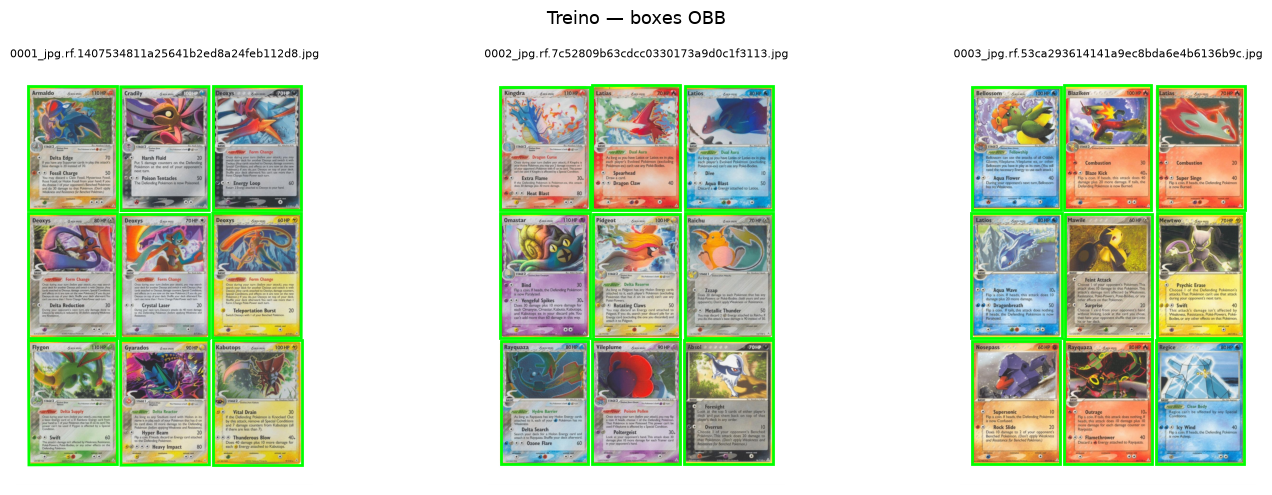

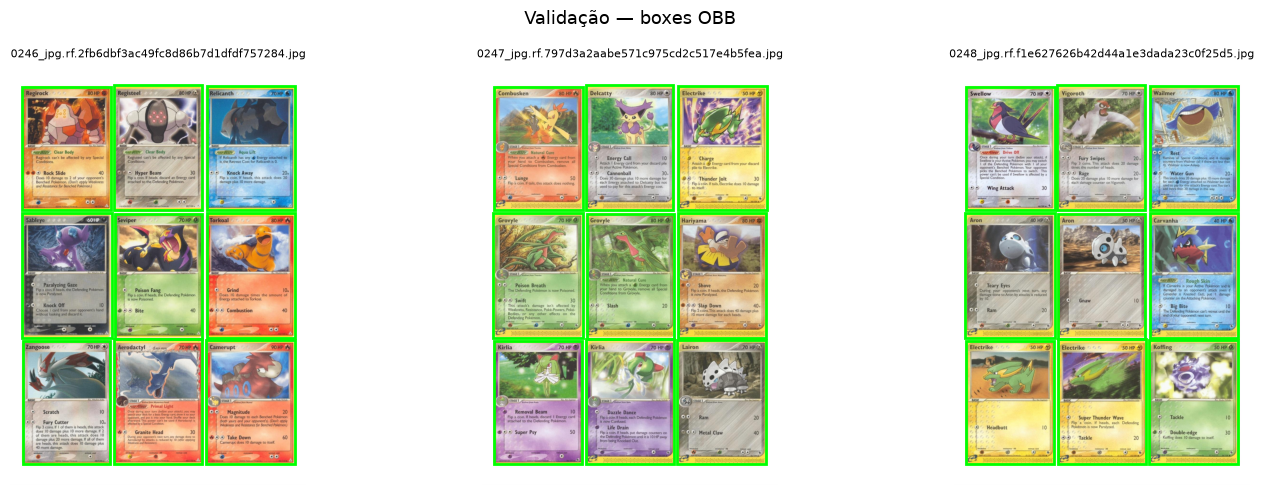

In [15]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon


def load_obb_polygons(label_path: Path, img_w: int, img_h: int) -> list[np.ndarray]:
    polys = []
    text = label_path.read_text(encoding="utf-8").strip()
    if not text:
        return polys
    for line in text.splitlines():
        parts = line.split()
        if len(parts) != 9:
            continue
        coords = np.array([float(x) for x in parts[1:]], dtype=float).reshape(4, 2)
        coords[:, 0] *= img_w
        coords[:, 1] *= img_h
        polys.append(coords)
    return polys


def show_obb_samples(split_dir: Path, n: int = 3, title: str = "Amostras OBB") -> None:
    images = list_images(split_dir / "images")[:n]
    if not images:
        print(f"Nenhuma imagem em {split_dir / 'images'}")
        return

    fig, axes = plt.subplots(1, len(images), figsize=(5 * len(images), 5))
    if len(images) == 1:
        axes = [axes]

    for ax, img_path in zip(axes, images):
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        label_path = split_dir / "labels" / f"{img_path.stem}.txt"
        ax.imshow(img)
        if label_path.exists():
            for poly in load_obb_polygons(label_path, w, h):
                ax.add_patch(
                    Polygon(poly, closed=True, fill=False, edgecolor="lime", linewidth=2)
                )
        ax.set_title(img_path.name, fontsize=8)
        ax.axis("off")

    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    plt.show()


show_obb_samples(DATASET_DIR / "train", n=3, title="Treino — boxes OBB")
show_obb_samples(DATASET_DIR / "valid", n=3, title="Validação — boxes OBB")


## 3. Treinamento (`obb-v5`)

Fine-tune do `obb-v3.pt` com a receita de borda do v4 (`imgsz=960`, mosaic/erasing off, `box/dfl/angle` altos, AdamW `lr0=0.001`) **mais** data augmentation de cor e pose.

- `project` absoluto em `runs/obb` (evita o aninhamento `runs/obb/runs/obb` do Ultralytics 8.4)
- `name=f'obb-{VERSION}'` → pasta `runs/obb/obb-v5/`
- `exist_ok=True` mantém o nome exato do experimento

### Data augmentation — o que entra e por quê

O dataset do Roboflow **não** vem com augmentação no export (só EXIF). O jitter abaixo é aplicado **só no treino**, a cada época; val/test ficam intactos.

| Transform | O que faz | Por que neste detector |
|---|---|---|
| `hsv_h` / `hsv_s` / `hsv_v` | Mexe matiz, saturação e brilho | Fotos de binder, scanner e PDF têm luz e cor muito diferentes; a classe é só `card`, então mudar a cor da arte **não** mistura classes |
| `degrees` | Rotaciona a imagem (e a OBB junto) | Cartas na mesa quase nunca estão alinhadas ao frame; o modelo OBB precisa ver ângulos |
| `translate` / `scale` | Desloca e aproxima/afasta | Enquadramento de celular vs foto de página inteira |
| `shear` (2°) | Inclinação leve | Telefone um pouco torto; valor pequeno para não virar trapézio irreal |
| `fliplr` / `flipud` | Espelha | Foto de cabeça para baixo / binder virado |

### O que **não** usamos (e por quê)

| Transform | Motivo de ficar em 0 |
|---|---|
| Mosaic | Cola 4 imagens numa grade; cartas cortadas e sobrepostas não são o layout do binder e estragam a borda |
| Mixup | Funde duas fotos; o polígono deixa de ser um retângulo de carta |
| Copy-paste | Copia objetos entre imagens; risco de cartas sobrepostas que o cropper não vê no uso real |
| Random erasing | Apaga um retângulo da imagem; esconde a borda que o warp precisa |
| Perspective | Empurra os 4 cantos de forma projetiva; a label OBB deixa de ser um retângulo rígido |

Se no val o **mAP50** subir e o **mAP75 / mAP50-95** cair, a augmentation geométrica está larga demais (caixas folgadas). Nesse caso baixe `degrees` / `scale` / `shear` antes de religar mosaic.


In [16]:
print(f"Iniciando treinamento: {EXPERIMENT_NAME}")
print(f"Dispositivo: {DEVICE} | modelo: {PRETRAINED_MODEL}")

model = YOLO(PRETRAINED_MODEL)

train_results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMGSZ,
    batch=BATCH,
    device=DEVICE,
    project=str(PROJECT_DIR),
    name=EXPERIMENT_NAME,
    exist_ok=True,
    patience=PATIENCE,
    seed=SEED,
    workers=WORKERS,
    pretrained=True,
    plots=True,
    val=True,
    verbose=True,
    **OPTIM,
    **LOSS,
    **AUGMENT,
)

save_dir = Path(model.trainer.save_dir)
bind_run_paths(save_dir)

print("\nTreinamento concluído.")
print(f"Run dir : {RUN_DIR}")
print(f"Weights : {WEIGHTS_DIR}")


Iniciando treinamento: obb-v5
Dispositivo: 0 | modelo: C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb\obb-v3\weights\obb-v3.pt
New https://pypi.org/project/ultralytics/8.4.169 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.129  Python-3.14.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8150MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=2.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=12.0, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\detection\data.yaml, degrees=30.0, deterministic=True, device=0, dfl=2.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.0, exist_ok=True, fliplr=0

## 4. Avaliação e métricas

Esta seção explica **o que cada número mede** e **por que entra neste TCC**. A célula seguinte só roda `model.val()` — não classifica o Pokémon e não avalia o OCR.

Há **uma classe** (`card`). Não existe tabela “por classe”: com `nc=1`, precision/recall/AP globais **são** os da única classe. O “m” de mAP (média entre classes) vira o AP dessa classe; o nome COCO/YOLO (`mAP50`, …) permanece para comparar com a literatura.

### Como um acerto é contado

O Ultralytics casa cada **caixa anotada** com cada **caixa prevista** usando **IoU de polígonos** (os quatro cantos da OBB), não caixa alinhada aos eixos e não pixels.

- **TP** — previu `card` e o polígono cobre a anotação acima do limiar de IoU  
- **FP** — previu `card` onde não havia carta (fundo, ficha, carta vizinha, caixa duplicada)  
- **FN** — havia carta anotada e o modelo não casou nenhuma predição  

Limiar padrão das curvas de mAP: 0,50; 0,75; e a média 0,50:0,95.

### Métricas que o notebook extrai

| Métrica | O que é | Por que usamos aqui |
|---|---|---|
| **Precision** | TP / (TP+FP) | Caixa extra vira recorte lixo e o OCR gasta tempo (ou inventa carta) |
| **Recall** | TP / (TP+FN) | Carta perdida **não entra no cropper** — é o erro mais caro do pipeline |
| **F1** | média harmônica de P e R | Um número só no ponto de operação; a curva F1 vs confiança justifica o `conf=0.8` da aplicação |
| **AP / mAP@0.50** | área sob a curva P–R com IoU ≥ 0,50 | “Achou a carta?”, com folga na borda. Protocolo padrão de detecção |
| **AP / mAP@0.75** | o mesmo com IoU ≥ 0,75 | A caixa precisa **encostar na borda impressa**: o cropper estica esse polígono para 63×88 mm |
| **AP / mAP@0.50:0.95** | média do AP em IoU 0,50 … 0,95 (passo 0,05) | Resumo COCO: achou **e** a borda está justa. Se mAP50 é alto e este cai, a caixa está larga |
| **TP, FP, FN** | cartas casadas / extras / perdidas (contagens, não um gráfico) | Unidades de carta; no val. No test o Ultralytics não monta a matriz se `plots=False` |
| **ms / imagem** | preprocess + inferência + pós-processo | Custo no scanner; não substitui mAP |

### Perdas (diagnóstico de treino, não “acerto”)

Vêm da última época em `results.csv`. Não substituem precision/recall.

| Perda | Papel |
|---|---|
| **Box** | Geometria do polígono (centro, largura, altura) |
| **DFL** | Refino da borda (Distribution Focal Loss) |
| **Angle** | Ângulo da OBB — específico deste detector; o warp depende dele |
| **Class** | Cabeça de classificação do YOLO. Com 1 classe quase não discrimina tipos; fica só como termo da loss, **não** como métrica de “qual Pokémon” |

### O que propositalmente **não** entra na tabela

- **Métricas por classe** (AP50/AP50-95 de cada nome) — só existe `card`; repetiria a tabela global. Faria sentido no ROI (`colection` / `name` / `number`).  
- **Acurácia de classificação / top-1** — não há classes de Pokémon neste modelo.  
- **Dice / mIoU de máscara** — a tarefa não é segmentação pixel a pixel.  
- **mAP de caixa axis-aligned** — subestima carta torta; o IoU da OBB já é o protocolo certo.  
- **Acerto no catálogo (OCR)** — isso é o `pipeline.ipynb`, não este detector.

Val é o split de ajuste. Se o YAML tiver `test`, a célula também reporta o **test** (mesmo conjunto de métricas, sem plots, para não sobrescrever os gráficos do val).


In [17]:
found_run = find_existing_run_dir()
if found_run:
    bind_run_paths(found_run)

ckpt_path = next(
    (
        path
        for path in (
            WEIGHTS_DIR / "best.pt",
            WEIGHTS_DIR / f"{EXPERIMENT_NAME}.pt",
            WEIGHTS_DIR / "last.pt",
        )
        if path.exists()
    ),
    None,
)
if ckpt_path is None:
    raise FileNotFoundError(
        f"Pesos não encontrados em {WEIGHTS_DIR}. "
        "Rode a célula de treinamento antes da validação."
    )

print(f"Validando {ckpt_path} ...")
val_model = YOLO(str(ckpt_path))

train_save_dir = Path(RUN_DIR)

metrics = val_model.val(
    data=str(DATA_YAML),
    split="val",
    imgsz=IMGSZ,
    device=DEVICE,
    project=str(PROJECT_DIR),
    name=EXPERIMENT_NAME,
    exist_ok=True,
    plots=True,
    workers=WORKERS,
    verbose=True,
)

bind_run_paths(train_save_dir)

metrics_test = None
if ds.get("has_test") and ds["splits"].get("test", {}).get("n_images", 0) > 0:
    print("\nValidando split test (plots=False, pasta de run inalterada) ...")
    metrics_test = val_model.val(
        data=str(DATA_YAML),
        split="test",
        imgsz=IMGSZ,
        device=DEVICE,
        project=str(PROJECT_DIR),
        name=f"{EXPERIMENT_NAME}-test",
        exist_ok=True,
        plots=False,
        workers=WORKERS,
        verbose=True,
    )
    bind_run_paths(train_save_dir)
else:
    print("\nSplit test ausente ou vazio — só o val será tabelado.")

print("Validação concluída.")
print(f"Run dir : {RUN_DIR}")


Validando C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb\obb-v5\weights\best.pt ...
Ultralytics 8.4.129  Python-3.14.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8150MiB)
YOLOv8n-obb summary (fused): 82 layers, 3,077,414 parameters, 0 gradients, 8.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 2254.0922.3 MB/s, size: 1290.3 KB)
val: Scanning C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\data\detection\valid\labels.cache... 71 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 71/71 33.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.3it/s 3.8s0.9ss
                   all         71        477      0.994      0.995      0.995      0.993
Speed: 0.6ms preprocess, 4.2ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb\obb-v5

Validando split test (

In [18]:
from typing import Any

import numpy as np


def _to_float(value: Any) -> float | None:
    if value is None:
        return None
    if isinstance(value, (float, int)):
        return float(value)
    if isinstance(value, (list, tuple)) and value:
        arr = np.asarray(value, dtype=float)
        return float(arr.mean())
    if isinstance(value, np.ndarray):
        if value.size == 0:
            return None
        return float(value.mean()) if value.ndim else float(value)
    if torch.is_tensor(value):
        return float(value.detach().cpu().mean())
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def get_obb_namespace(metrics_obj) -> Any:
    """Ultralytics expõe métricas OBB em .obb; algumas versões reutilizam .box."""
    if hasattr(metrics_obj, "obb") and metrics_obj.obb is not None:
        ns = metrics_obj.obb
        if _to_float(getattr(ns, "map", None)) is not None:
            return ns, "obb"
    if hasattr(metrics_obj, "box") and metrics_obj.box is not None:
        return metrics_obj.box, "box"
    raise AttributeError("Não foi possível localizar metrics.obb nem metrics.box.")


def extract_confusion_counts(metrics_obj) -> dict[str, int | None]:
    """TP/FP/FN da matriz YOLO (caixas). Última linha/coluna = fundo."""
    cm_obj = getattr(metrics_obj, "confusion_matrix", None)
    matrix = getattr(cm_obj, "matrix", None) if cm_obj is not None else None
    if matrix is None:
        return {"TP": None, "FP": None, "FN": None}
    m = np.asarray(matrix, dtype=float)
    if m.ndim != 2 or min(m.shape) < 2:
        return {"TP": None, "FP": None, "FN": None}
    nc = m.shape[0] - 1
    tp = int(round(np.trace(m[:nc, :nc])))
    fp = int(round(m[:nc, nc].sum()))
    fn = int(round(m[nc, :nc].sum()))
    return {"TP": tp, "FP": fp, "FN": fn}


def extract_speed_ms(metrics_obj) -> float | None:
    speed = getattr(metrics_obj, "speed", None)
    if not isinstance(speed, dict):
        return None
    total = 0.0
    n = 0
    for key in ("preprocess", "inference", "postprocess"):
        val = speed.get(key)
        if val is None:
            continue
        total += float(val)
        n += 1
    return total if n else None


def extract_detection_metrics(metrics_obj) -> pd.DataFrame:
    """Uma linha por métrica. nc=1 → sem bloco 'por classe'."""
    ns, source = get_obb_namespace(metrics_obj)
    print(f"Namespace de métricas: metrics.{source}")

    precision = _to_float(getattr(ns, "mp", None))
    recall = _to_float(getattr(ns, "mr", None))
    f1 = None
    if precision is not None and recall is not None and (precision + recall) > 0:
        f1 = 2.0 * precision * recall / (precision + recall)

    counts = extract_confusion_counts(metrics_obj)
    speed = extract_speed_ms(metrics_obj)
    has_counts = any(counts[k] not in (None, 0) for k in ("TP", "FP", "FN"))

    rows = [
        {
            "Métrica": "Precision",
            "Valor": precision,
            "Por que": "Caixa extra → recorte/OCR a mais",
        },
        {
            "Métrica": "Recall",
            "Valor": recall,
            "Por que": "Carta perdida não chega ao cropper",
        },
        {
            "Métrica": "F1",
            "Valor": f1,
            "Por que": "P e R juntos; a curva F1 escolhe o conf da app",
        },
        {
            "Métrica": "mAP@0.50",
            "Valor": _to_float(getattr(ns, "map50", None)),
            "Por que": "Achou a carta? (IoU ≥ 0,50, protocolo padrão)",
        },
        {
            "Métrica": "mAP@0.75",
            "Valor": _to_float(getattr(ns, "map75", None)),
            "Por que": "Caixa justa o bastante para o warp 63×88 mm",
        },
        {
            "Métrica": "mAP@0.50:0.95",
            "Valor": _to_float(getattr(ns, "map", None)),
            "Por que": "Média COCO: detecção + qualidade da borda",
        },
        {
            "Métrica": "Tempo (ms/img)",
            "Valor": speed,
            "Por que": "Preprocess + inferência + NMS (não é mAP)",
        },
    ]
    if has_counts:
        rows[6:6] = [
            {
                "Métrica": "TP (caixas)",
                "Valor": counts["TP"],
                "Por que": "Cartas casadas (contagem, sem matriz plotada)",
            },
            {
                "Métrica": "FP (caixas)",
                "Valor": counts["FP"],
                "Por que": "Predições sem anotação (fundo / duplicata)",
            },
            {
                "Métrica": "FN (caixas)",
                "Valor": counts["FN"],
                "Por que": "Anotações sem predição",
            },
        ]
    return pd.DataFrame(rows)


def extract_val_losses(run_dir: Path) -> pd.DataFrame:
    csv_path = run_dir / "results.csv"
    if not csv_path.exists():
        return pd.DataFrame(columns=["Perda", "Valor", "Papel"])

    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    last = df.iloc[-1]

    wanted = [
        ("Box Loss", ["val/box_loss", "metrics/box_loss"], "Geometria do polígono"),
        ("DFL Loss", ["val/dfl_loss", "metrics/dfl_loss"], "Refino da borda"),
        ("Angle Loss", ["val/angle_loss", "metrics/angle_loss", "train/angle_loss"], "Rotação da OBB (warp)"),
        ("Class Loss", ["val/cls_loss", "metrics/cls_loss"], "Termo YOLO; 1 classe ≠ tipo de Pokémon"),
    ]

    rows = []
    for label, candidates, role in wanted:
        col = next((c for c in candidates if c in df.columns), None)
        value = float(last[col]) if col is not None else None
        rows.append({"Perda": label, "Valor": value, "Papel": role})
    return pd.DataFrame(rows)


def _fmt_metric_table(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    count_names = {"TP (caixas)", "FP (caixas)", "FN (caixas)"}

    def _round(row):
        x = row["Valor"]
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return None
        if row["Métrica"] in count_names:
            return int(round(float(x)))
        return round(float(x), 4)

    out["Valor"] = out.apply(_round, axis=1)
    return out


print("=" * 72)
print(f"Métricas de detecção (1 classe `card`) — val — {EXPERIMENT_NAME}")
print("=" * 72)
val_df = _fmt_metric_table(extract_detection_metrics(metrics))
display(val_df)

if metrics_test is not None:
    print()
    print("=" * 72)
    print(f"Métricas de detecção — test — {EXPERIMENT_NAME}")
    print("=" * 72)
    test_df = _fmt_metric_table(extract_detection_metrics(metrics_test))
    display(test_df)

print("\nPerdas da última época (results.csv do treino) — diagnóstico, não ranking de acerto")
loss_df = extract_val_losses(RUN_DIR)
loss_df["Valor"] = loss_df["Valor"].map(lambda x: None if x is None else round(x, 4))
display(loss_df)

print("\nResumo (val)")
g = {row["Métrica"]: row["Valor"] for _, row in val_df.iterrows()}
l = {row["Perda"]: row["Valor"] for _, row in loss_df.iterrows()}
print(f"  Precision       = {g.get('Precision')}")
print(f"  Recall          = {g.get('Recall')}")
print(f"  F1              = {g.get('F1')}")
print(f"  mAP@0.50        = {g.get('mAP@0.50')}")
print(f"  mAP@0.75        = {g.get('mAP@0.75')}")
print(f"  mAP@0.50:0.95   = {g.get('mAP@0.50:0.95')}")
print(f"  TP / FP / FN    = {g.get('TP (caixas)')} / {g.get('FP (caixas)')} / {g.get('FN (caixas)')}")
print(f"  Box / DFL / Angle loss = {l.get('Box Loss')} / {l.get('DFL Loss')} / {l.get('Angle Loss')}")


Métricas de detecção (1 classe `card`) — val — obb-v5
Namespace de métricas: metrics.box


,Métrica,Valor,Por que
0,Precision,0.9937,Caixa extra → recorte/OCR a mais
1,Recall,0.9948,Carta perdida não chega ao cropper
2,F1,0.9943,P e R juntos; a curva F1 escolhe o conf da app
3,mAP@0.50,0.9950,"Achou a carta? (IoU ≥ 0,50, protocolo padrão)"
4,mAP@0.75,0.9950,Caixa justa o bastante para o warp 63×88 mm
5,mAP@0.50:0.95,0.9926,Média COCO: detecção + qualidade da borda
6,TP (caixas),477.0000,Cartas casadas na matriz de contagens
7,FP (caixas),13.0000,Predições sem anotação (fundo / duplicata)
8,FN (caixas),0.0000,Anotações sem predição
9,Tempo (ms/img),7.0775,Preprocess + inferência + NMS (não é mAP)



Métricas de detecção — test — obb-v5
Namespace de métricas: metrics.box


,Métrica,Valor,Por que
0,Precision,1.0000,Caixa extra → recorte/OCR a mais
1,Recall,0.9918,Carta perdida não chega ao cropper
2,F1,0.9959,P e R juntos; a curva F1 escolhe o conf da app
3,mAP@0.50,0.9950,"Achou a carta? (IoU ≥ 0,50, protocolo padrão)"
4,mAP@0.75,0.9950,Caixa justa o bastante para o warp 63×88 mm
5,mAP@0.50:0.95,0.9916,Média COCO: detecção + qualidade da borda
6,TP (caixas),0.0000,Cartas casadas na matriz de contagens
7,FP (caixas),0.0000,Predições sem anotação (fundo / duplicata)
8,FN (caixas),0.0000,Anotações sem predição
9,Tempo (ms/img),9.0554,Preprocess + inferência + NMS (não é mAP)



Perdas da última época (results.csv do treino) — diagnóstico, não ranking de acerto


,Perda,Valor,Papel
0,Box Loss,0.2885,Geometria do polígono
1,DFL Loss,1.5122,Refino da borda
2,Angle Loss,0.0062,Rotação da OBB (warp)
3,Class Loss,0.1428,Termo YOLO; 1 classe ≠ tipo de Pokémon



Resumo (val)
  Precision       = 0.9937
  Recall          = 0.9948
  F1              = 0.9943
  mAP@0.50        = 0.995
  mAP@0.75        = 0.995
  mAP@0.50:0.95   = 0.9926
  TP / FP / FN    = 477.0 / 13.0 / 0.0
  Box / DFL / Angle loss = 0.2885 / 1.5122 / 0.0062


## 5. Gráficos e artefatos visuais

Exibe os arquivos gerados pelo Ultralytics **no val** (o test foi rodado sem plots):

- Curva **F1 vs confiança** — o pico (~0,79 no v3) é o motivo de `conf=0.8` no cropper
- Curva Precision–Recall (a área é o AP@0.50)
- `results.png` e lotes `val_batch*_labels.jpg` / `val_batch*_pred.jpg`

Não mostramos as duas matrizes de confusão (contagens e normalizada). Com **uma classe** `card` a normalizada é enganosa (fundo→fundo é sempre 0; fundo→carta vira 1.00 só porque todo FP é “previu carta”). Os TP/FP/FN já entram como números na tabela da seção 4.


Curva F1 vs Confidence  →  C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb\obb-v5\BoxF1_curve.png


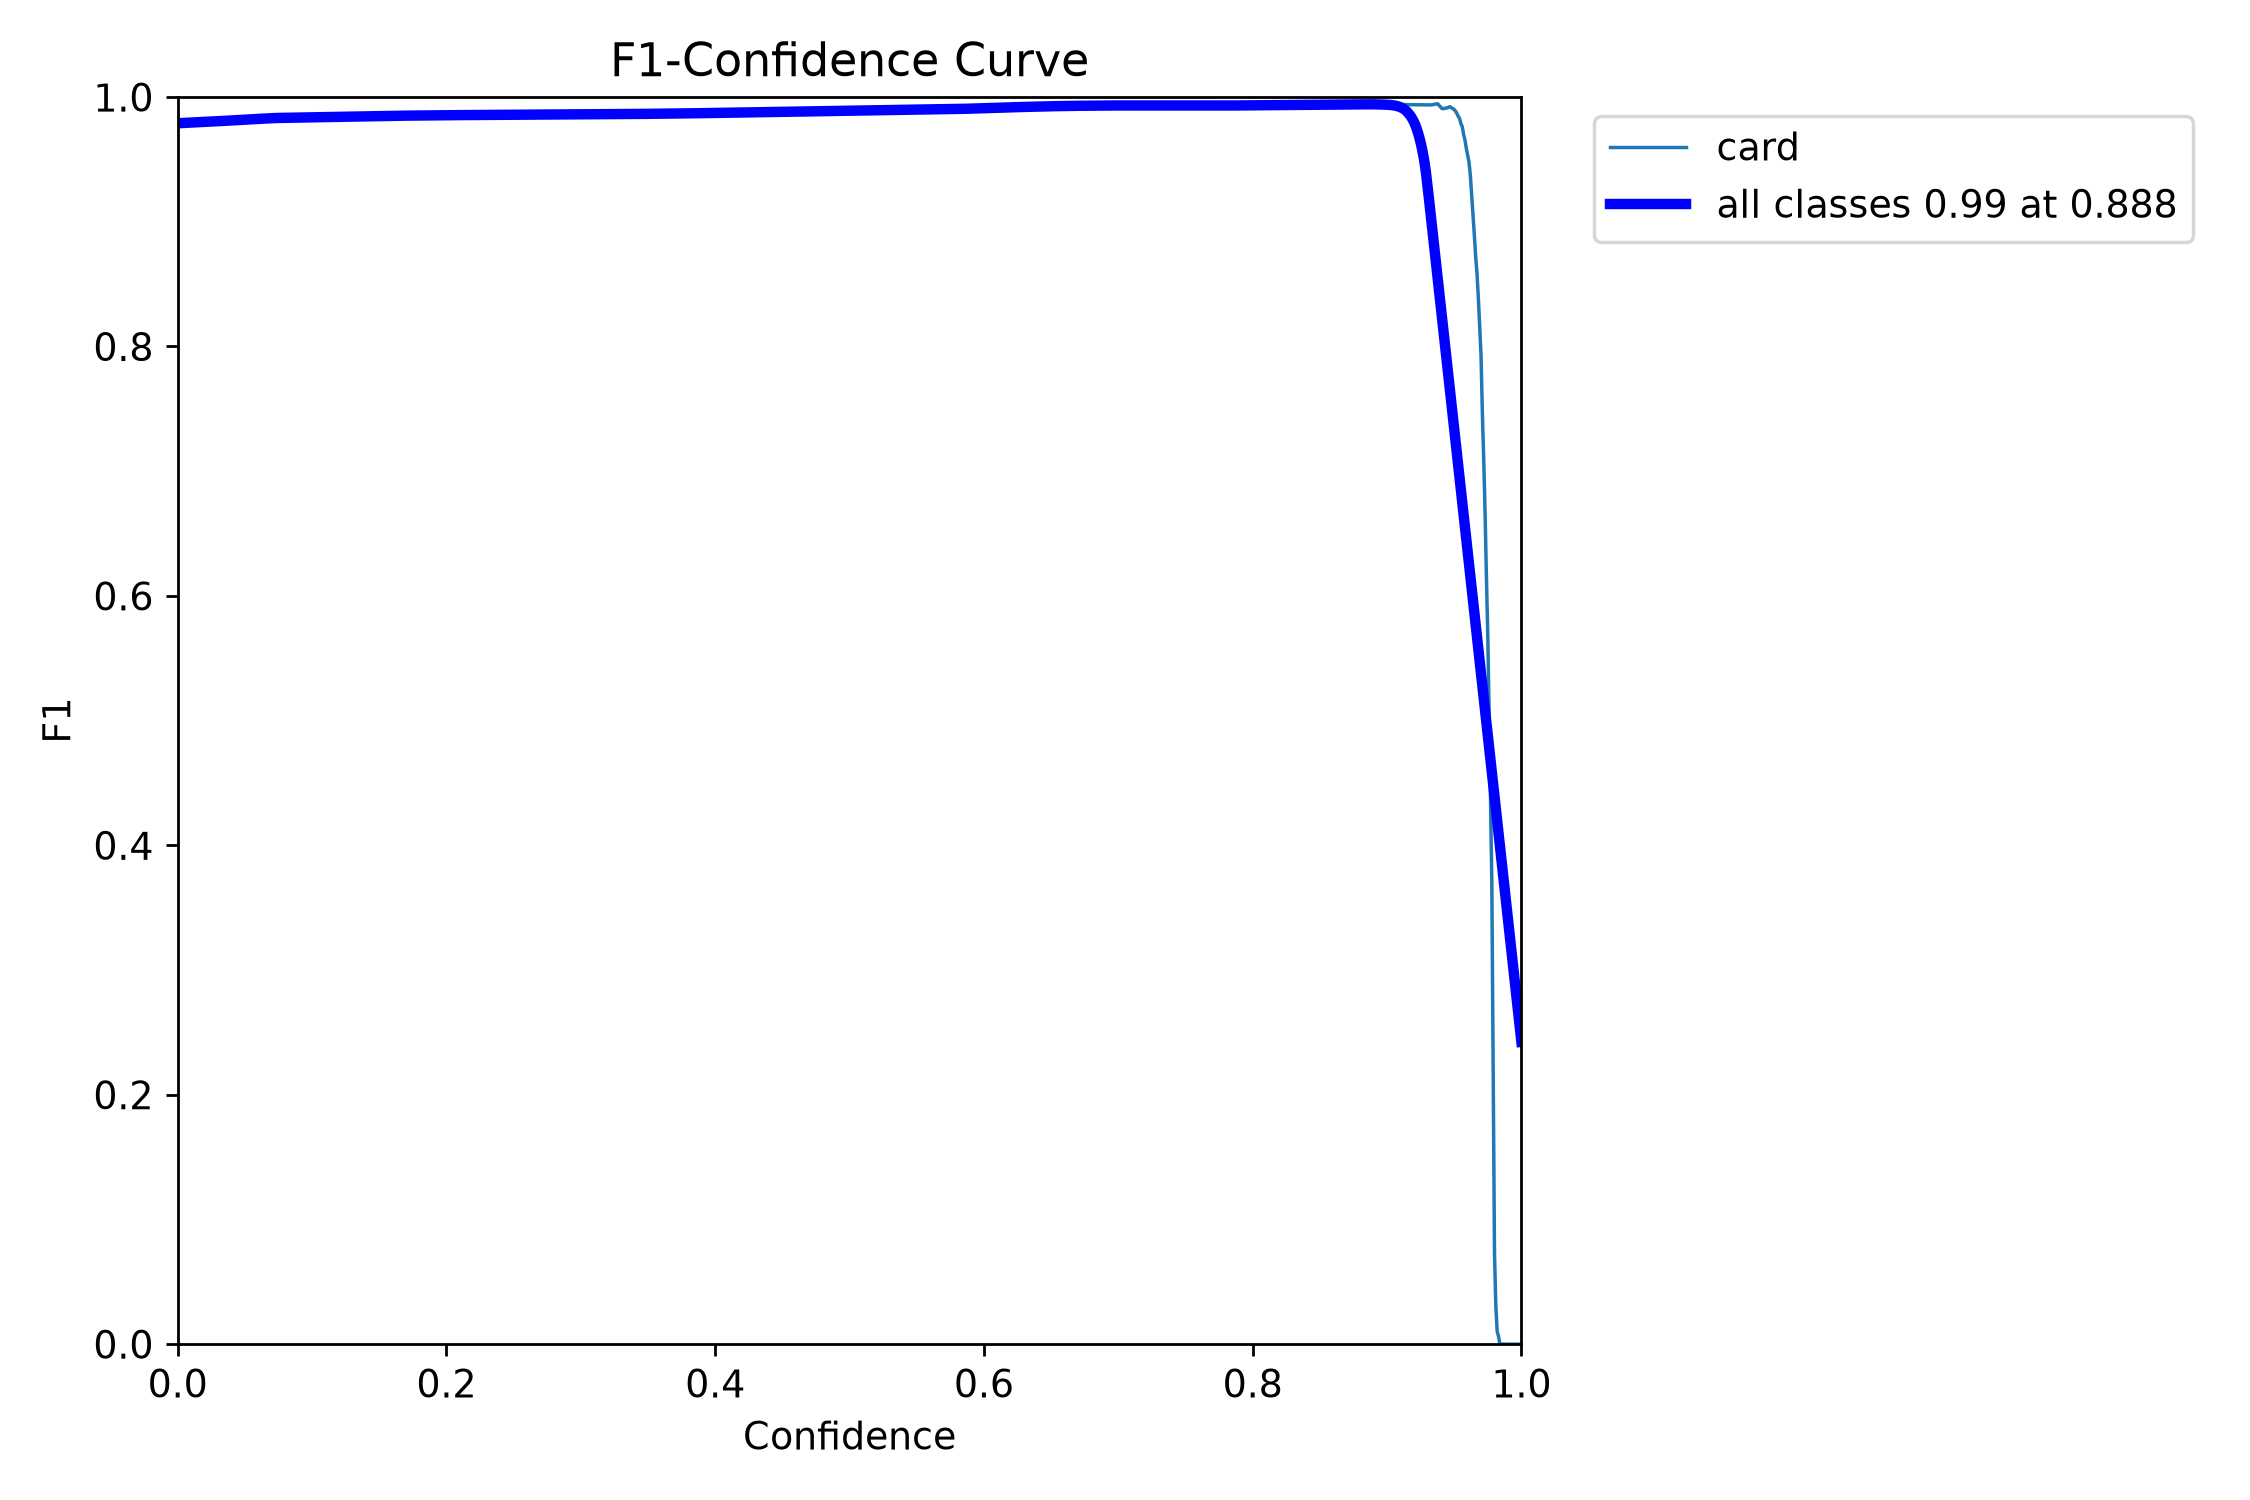

Curva Precision–Recall  →  C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb\obb-v5\BoxPR_curve.png


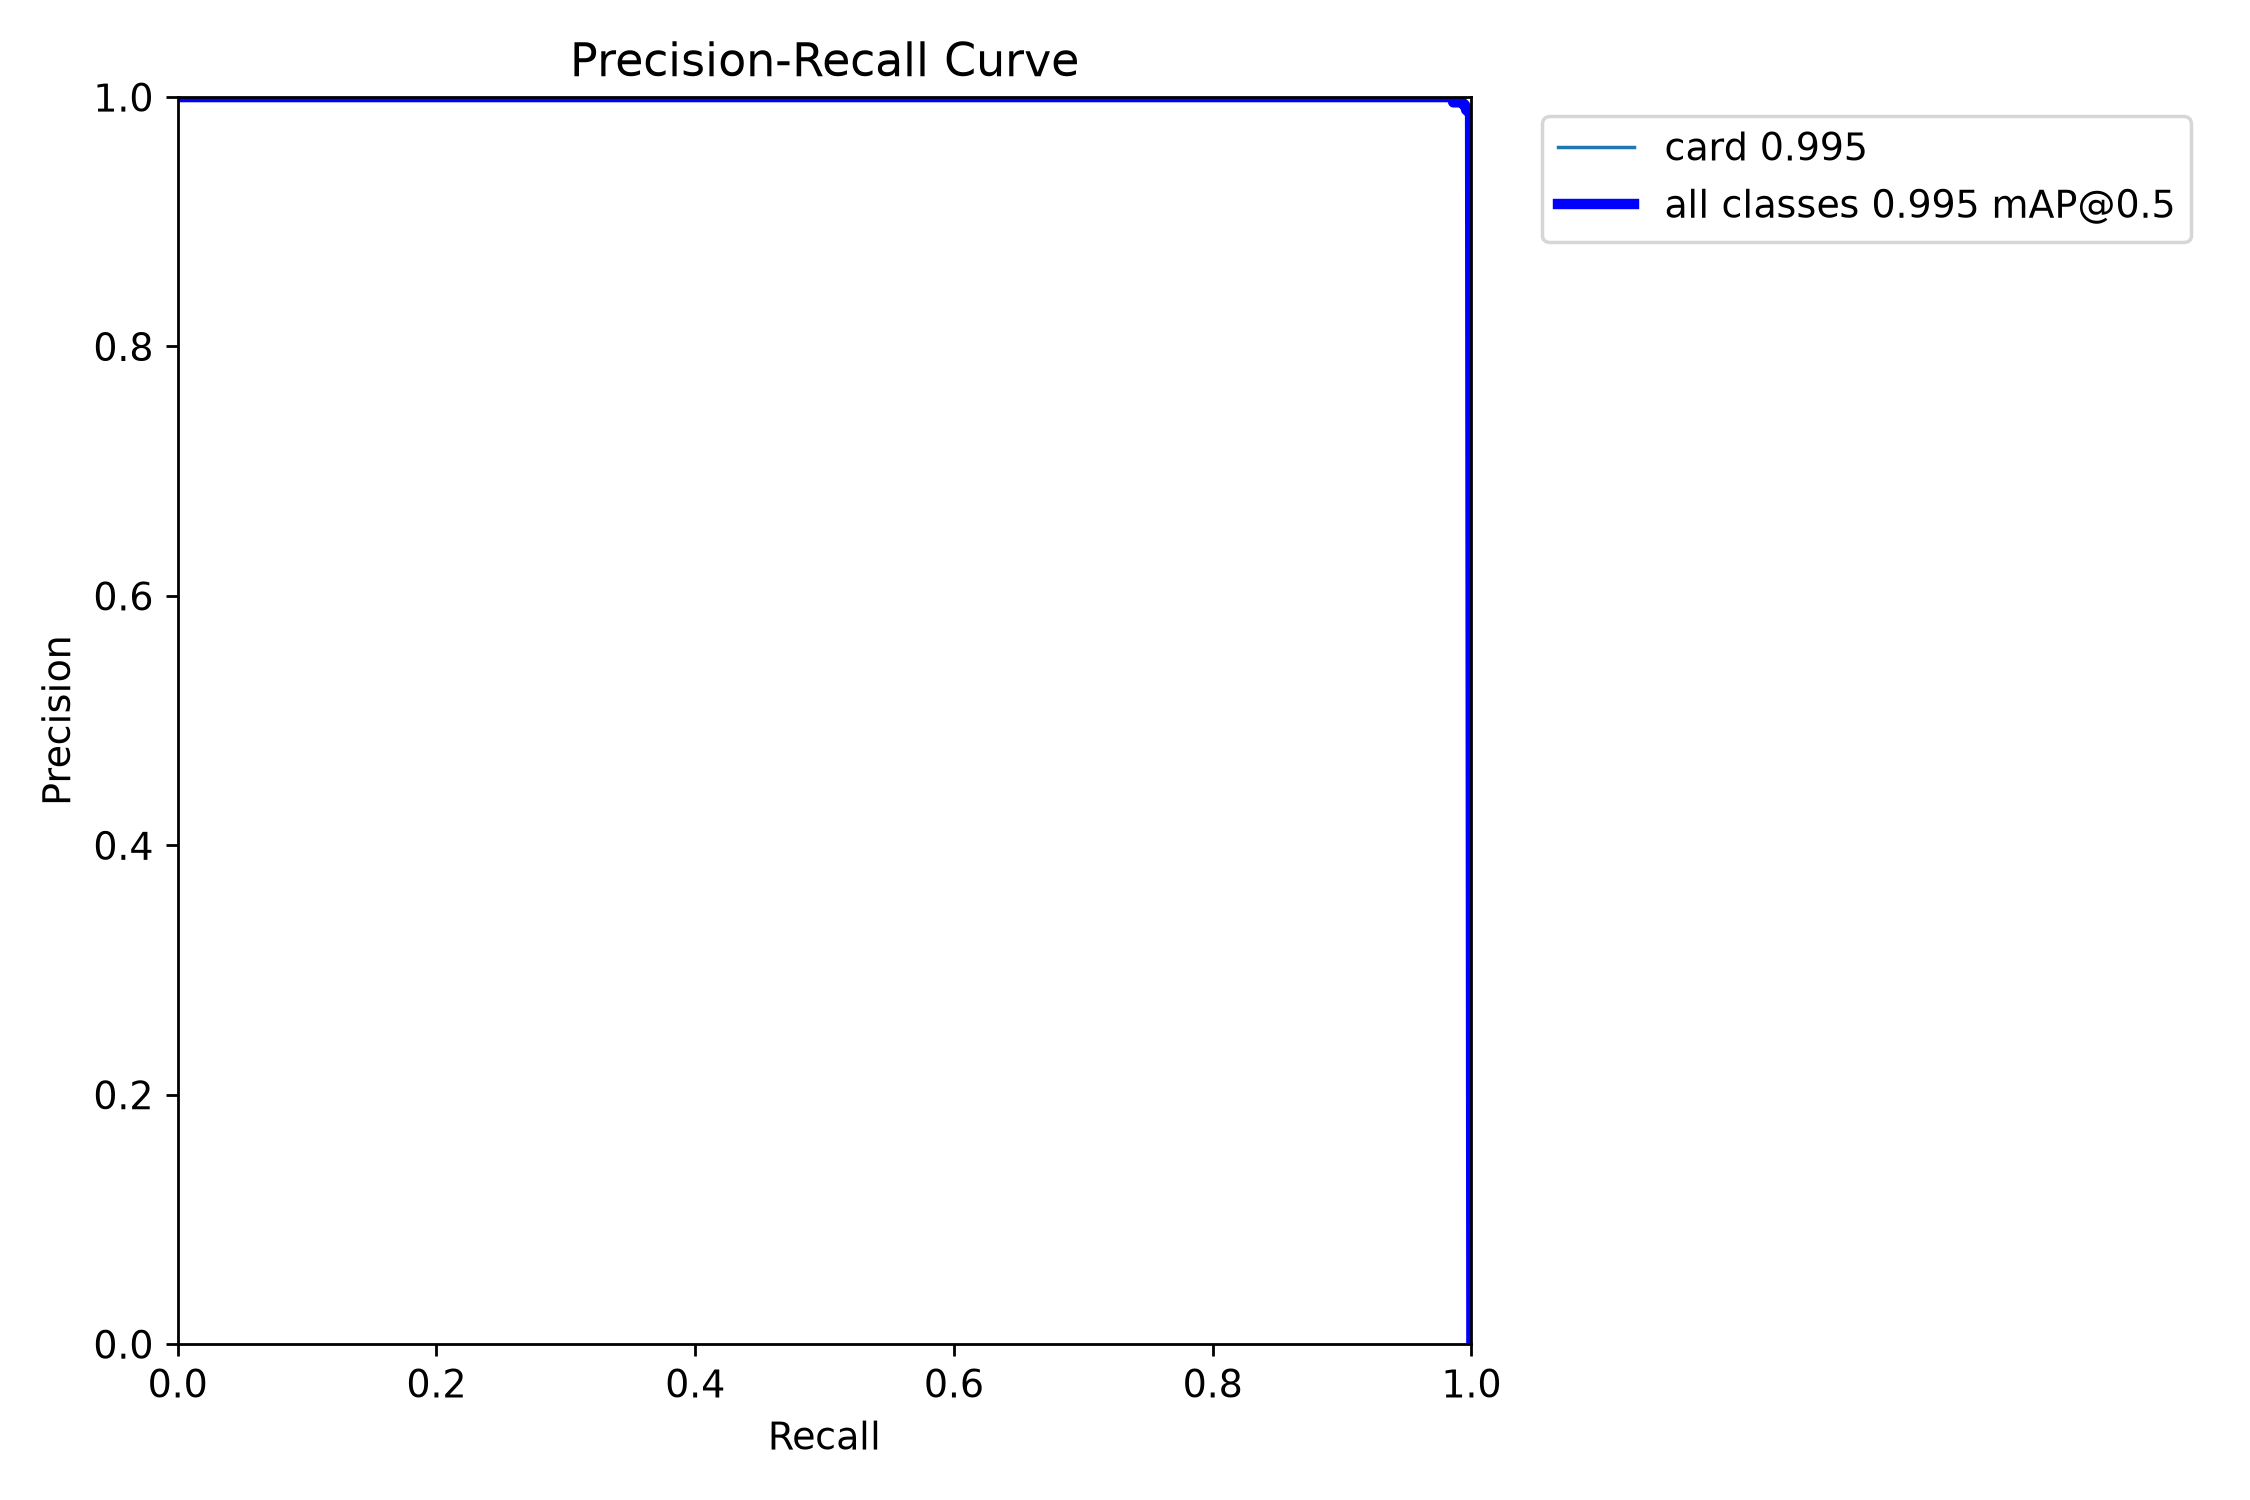

Curvas de treino (results.png)  →  C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb\obb-v5\results.png


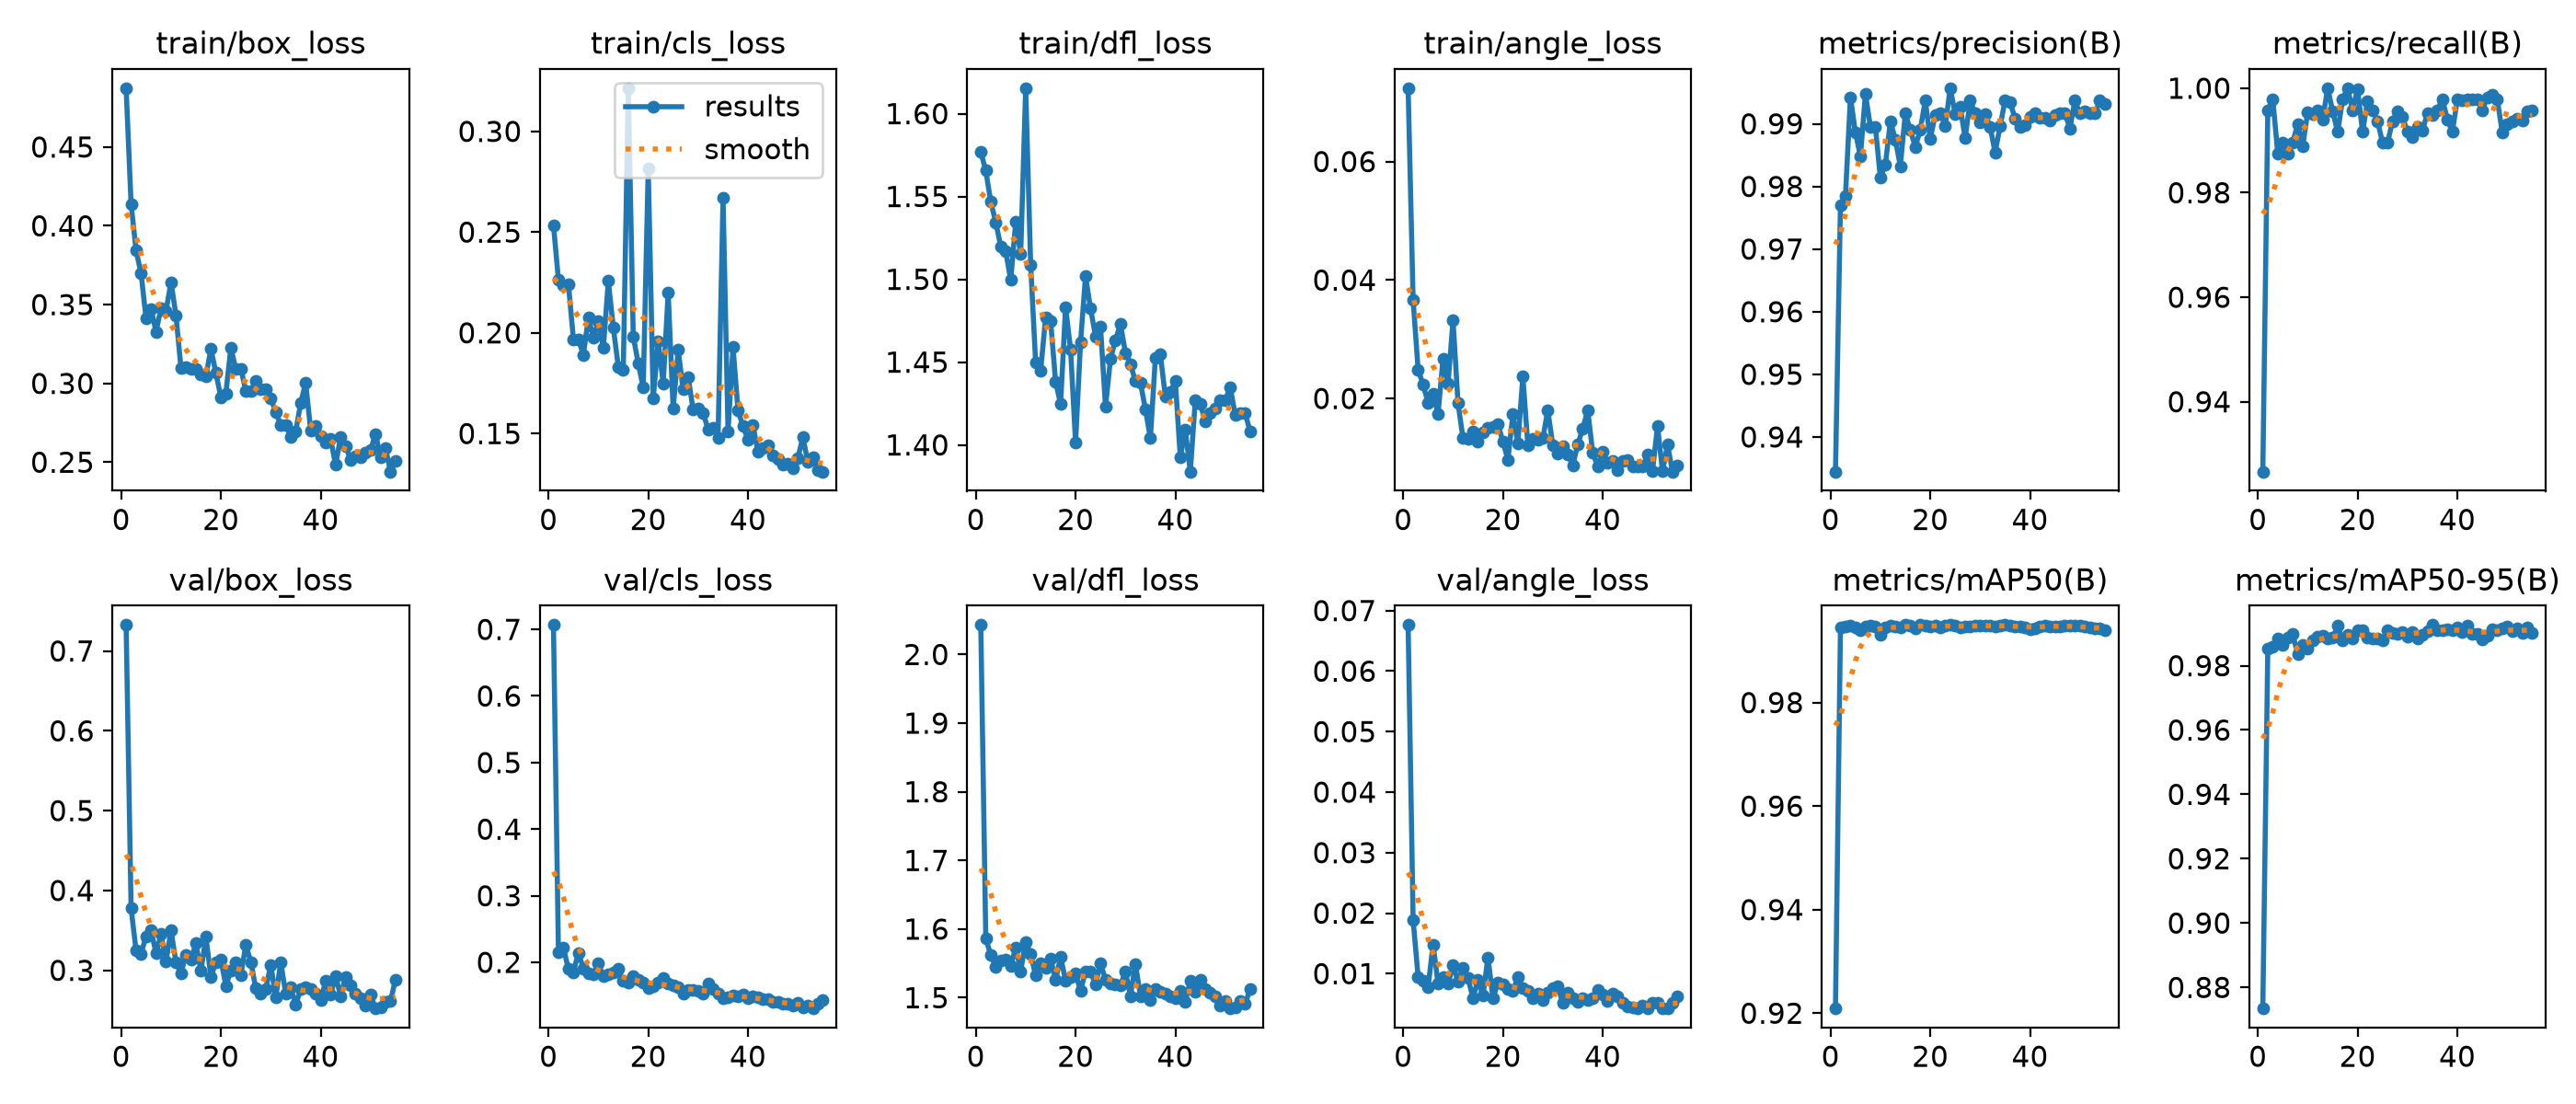

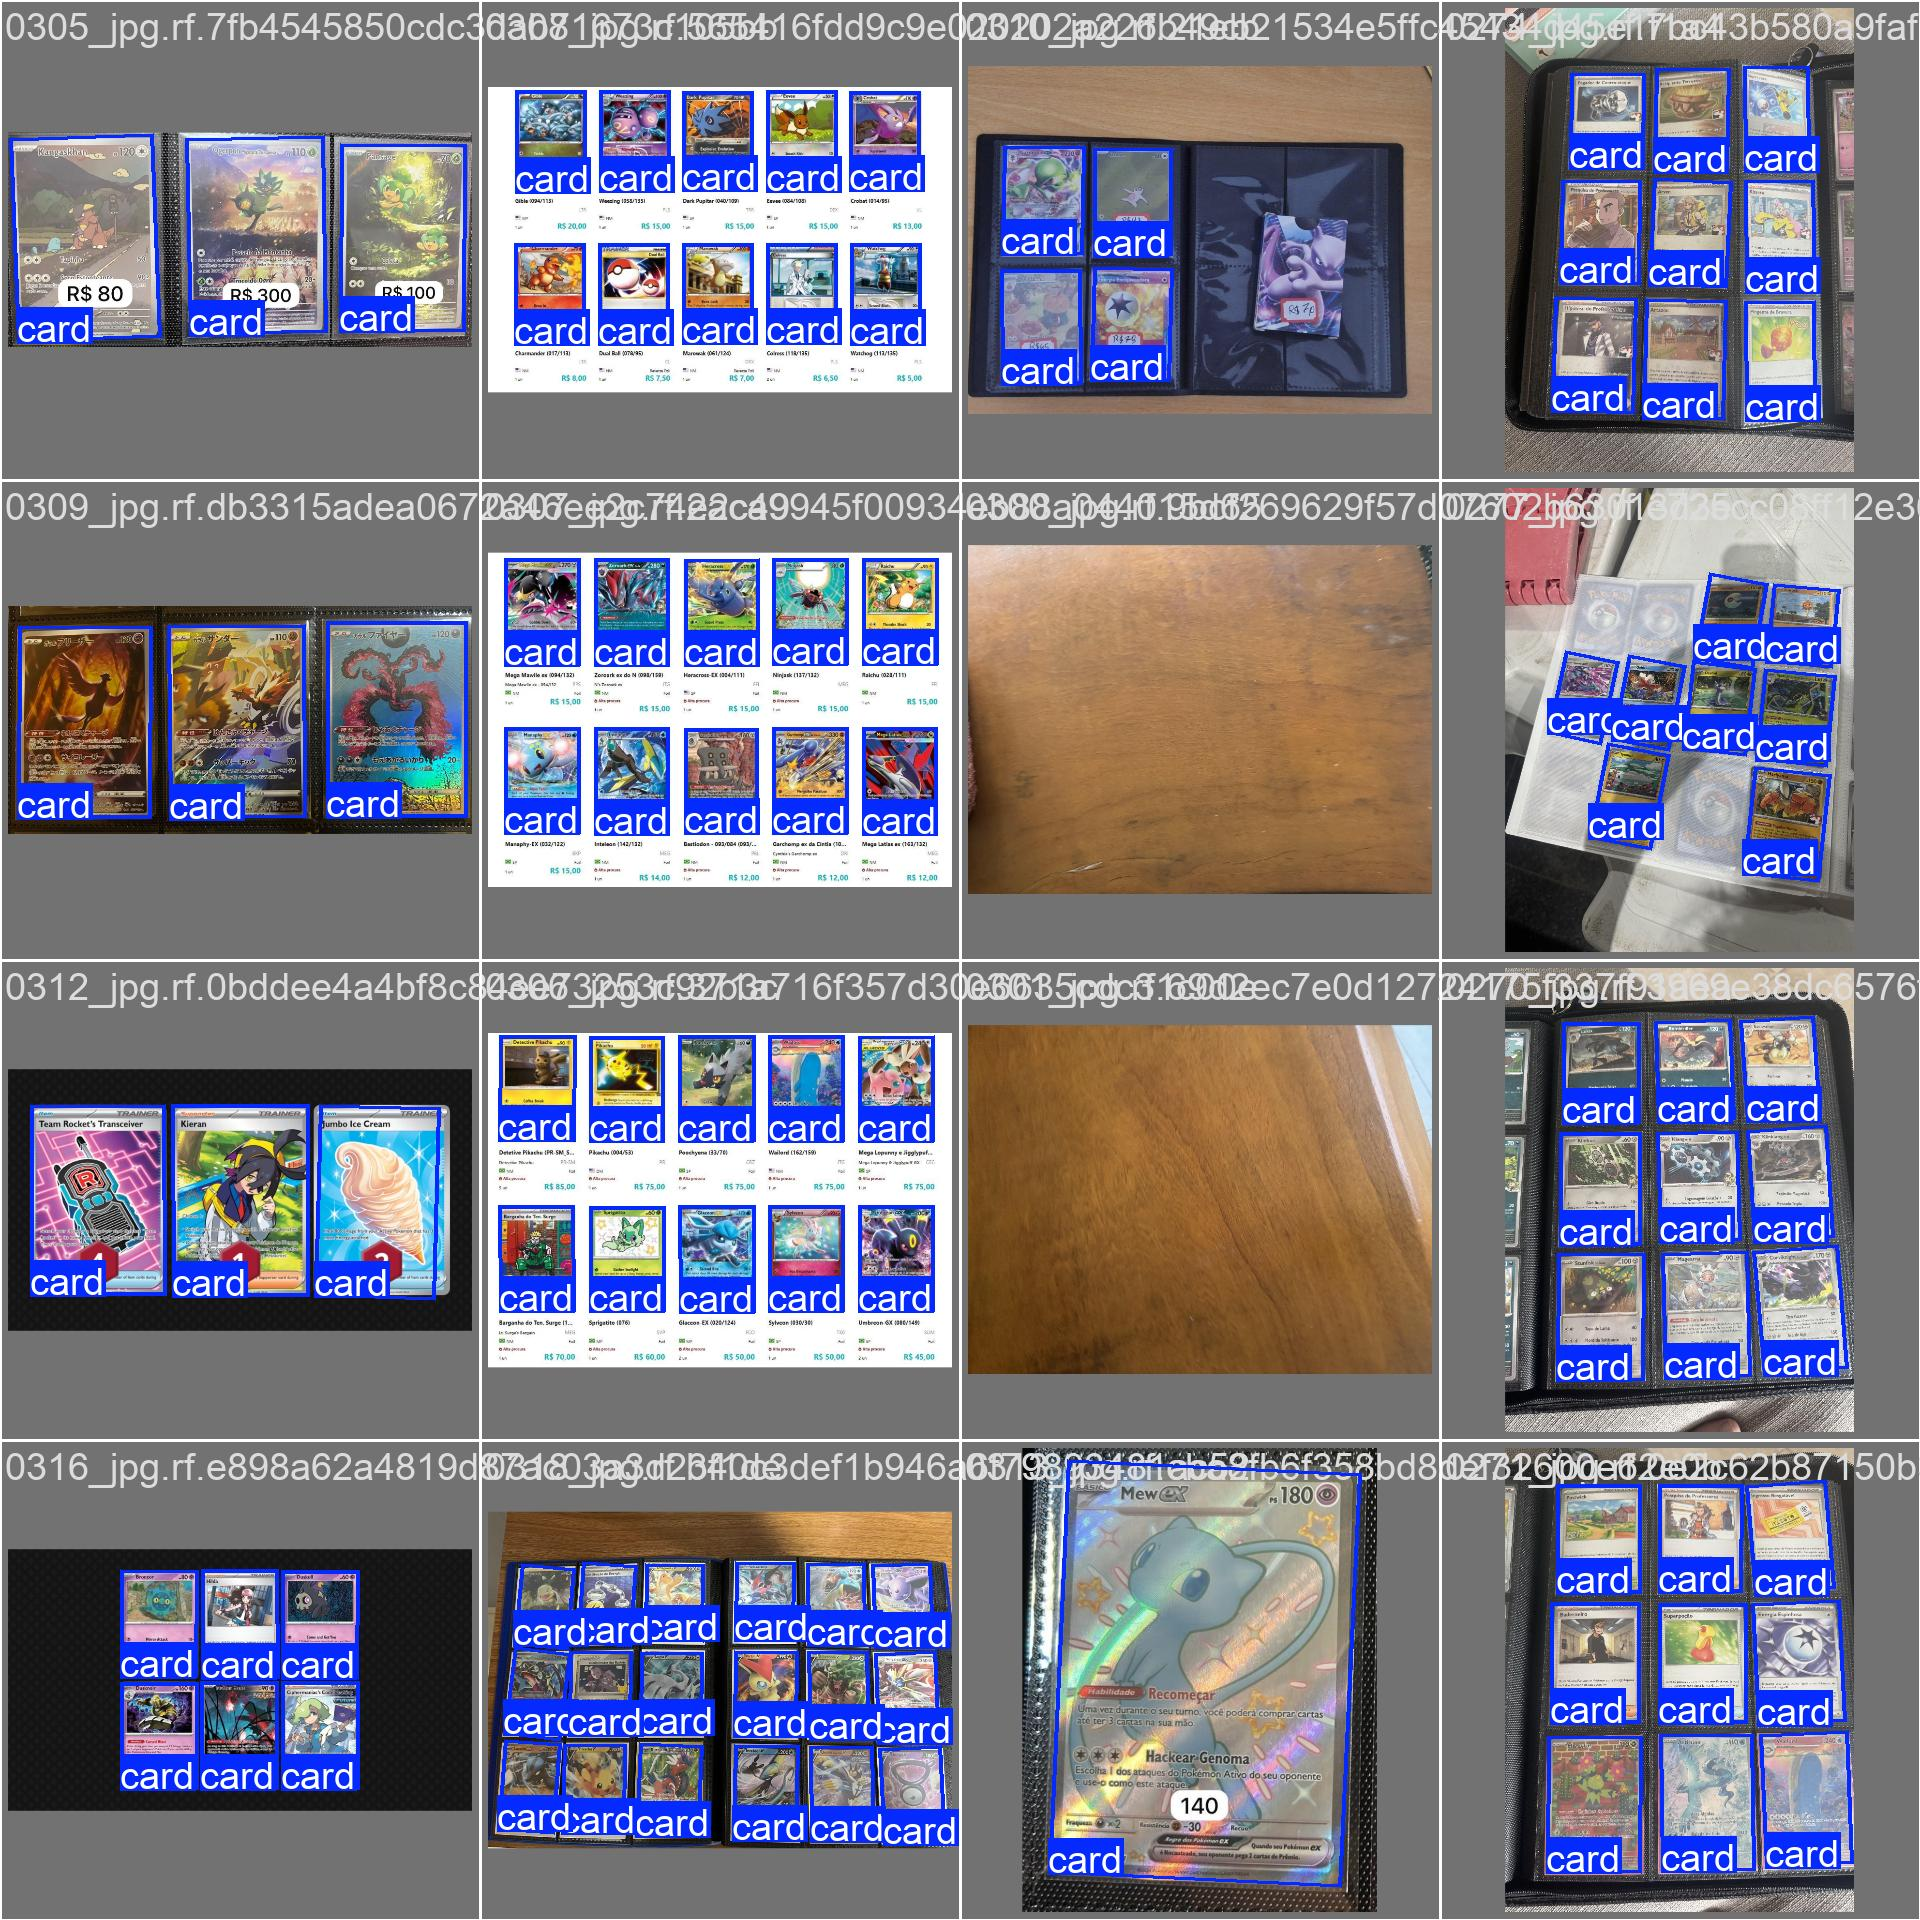

val_batch1_labels.jpg


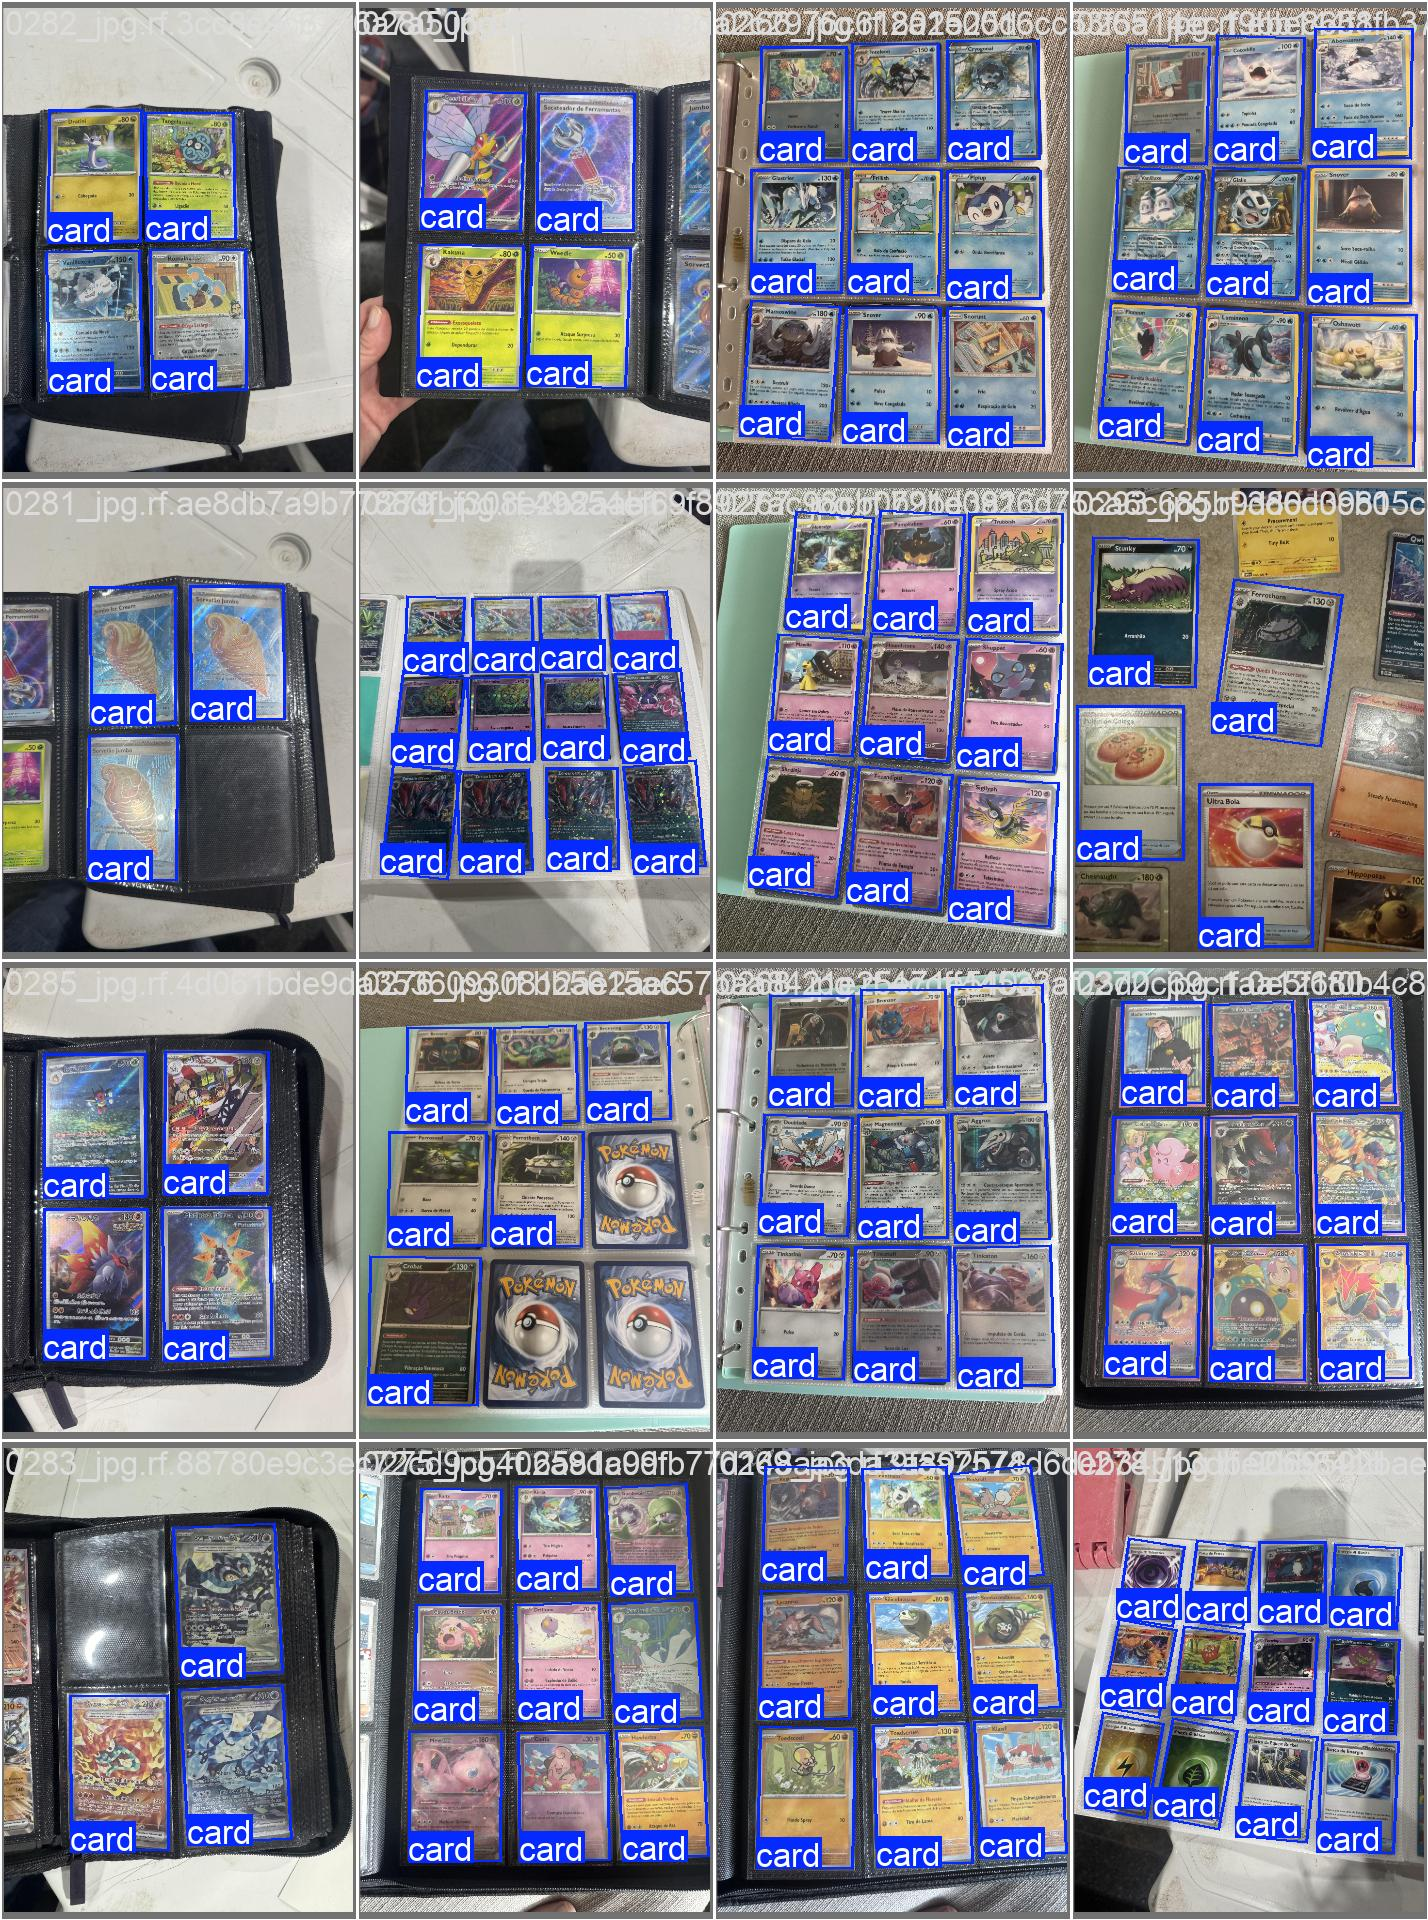

val_batch2_labels.jpg


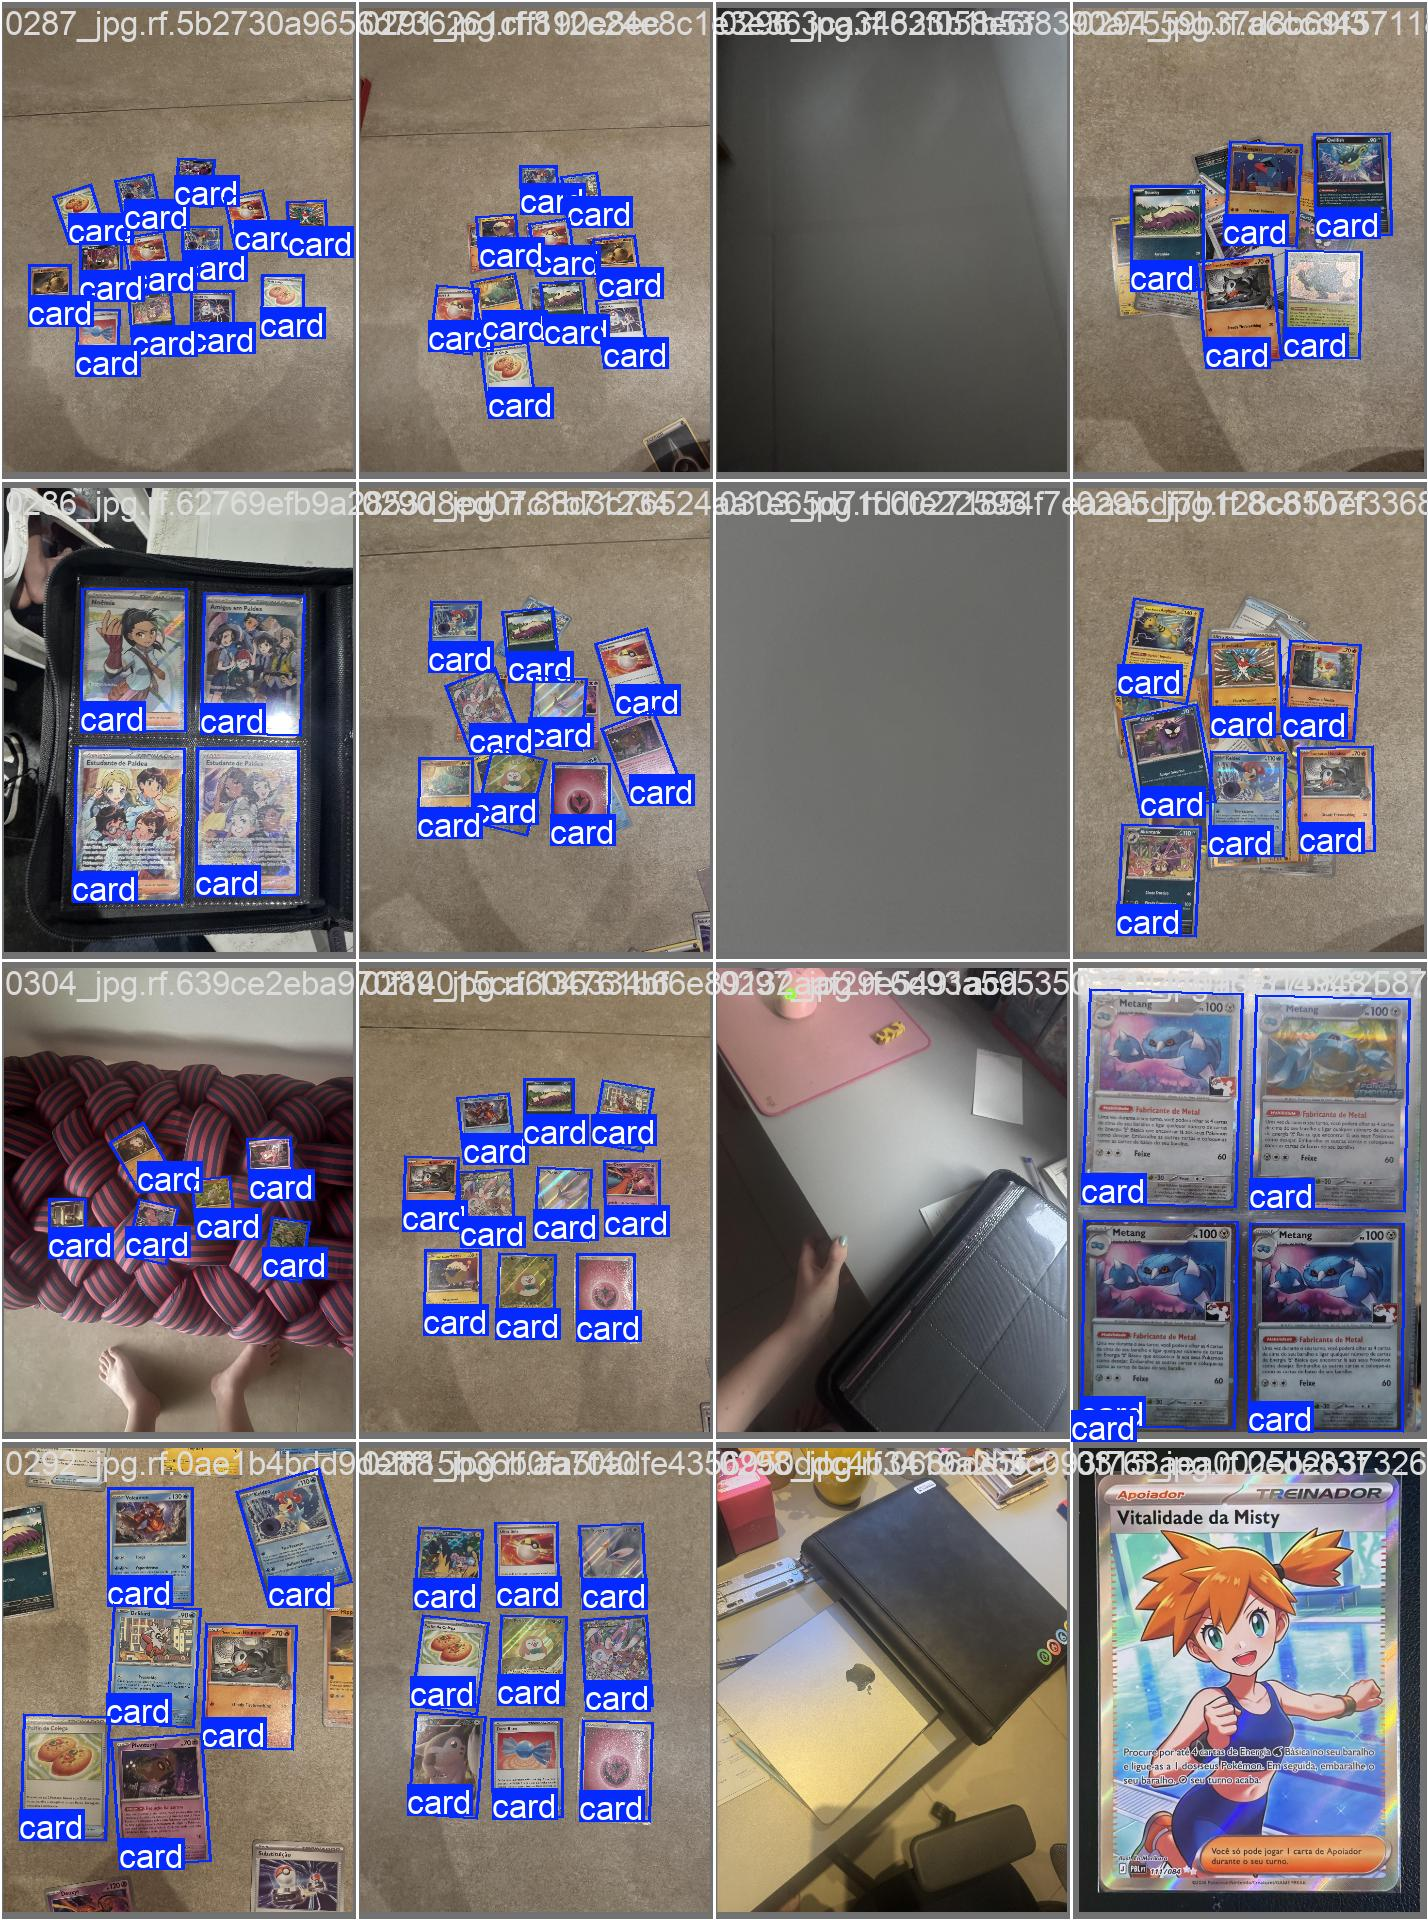

val_batch0_pred.jpg


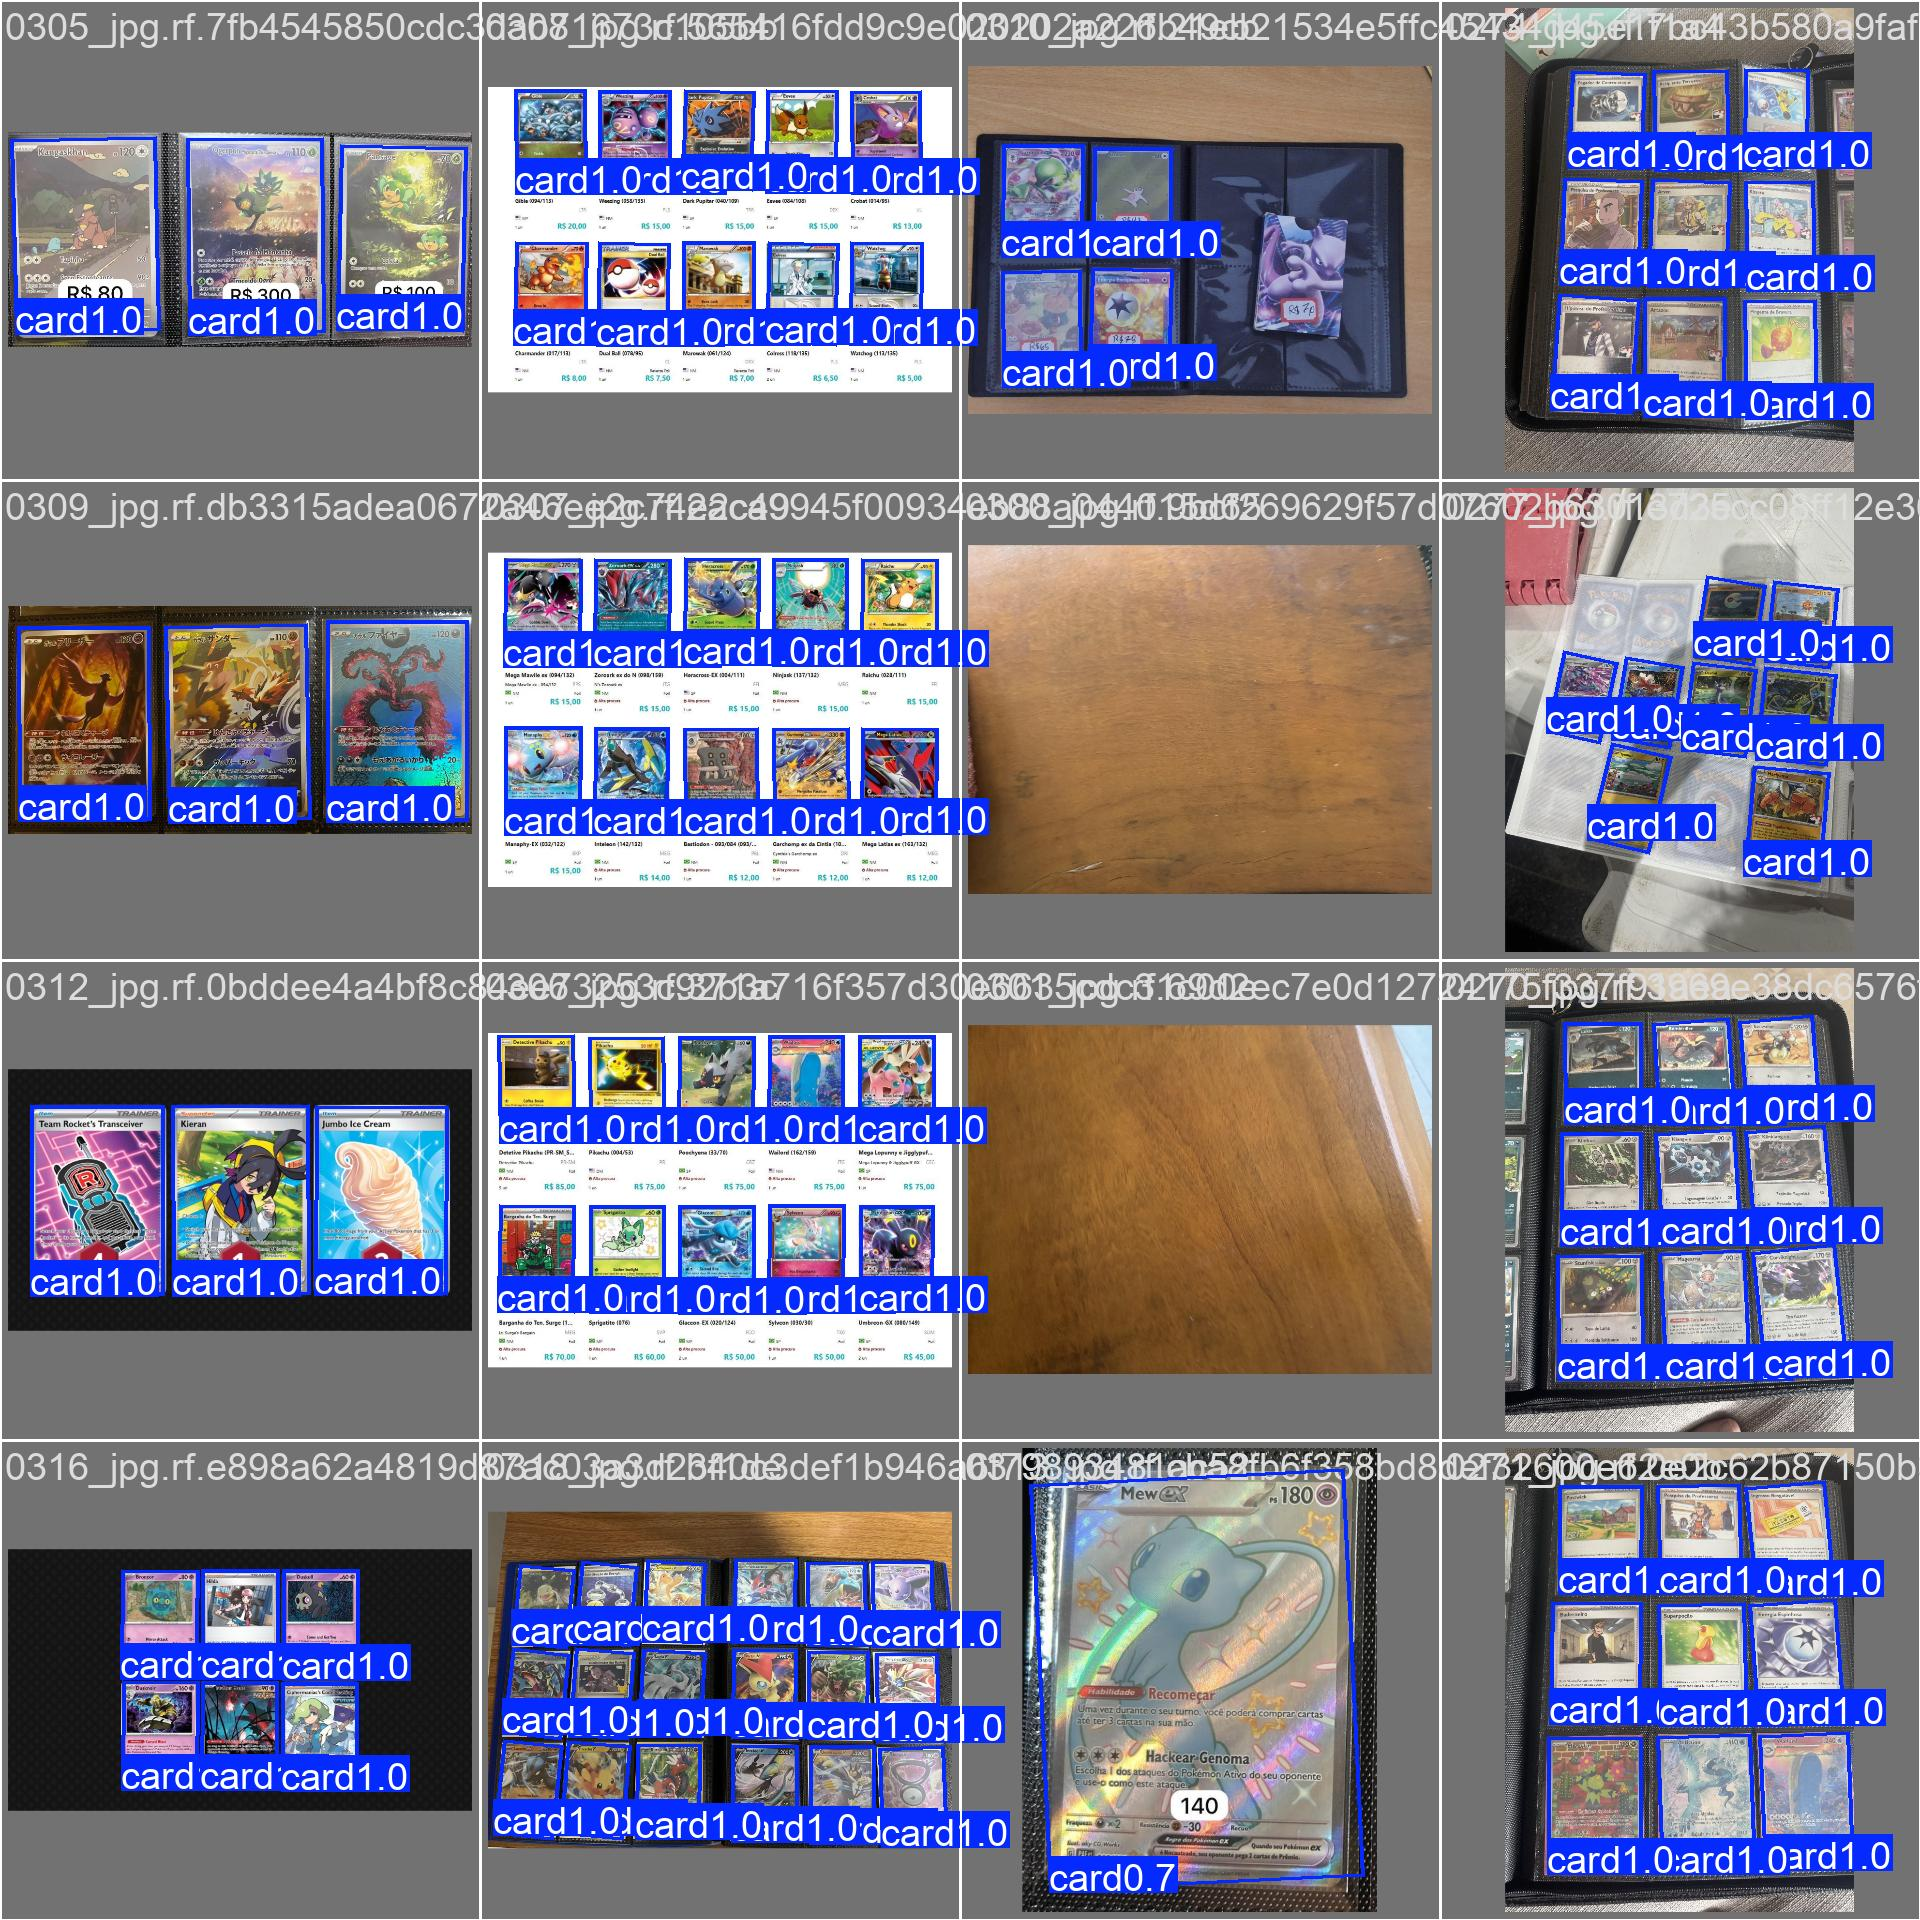

val_batch1_pred.jpg


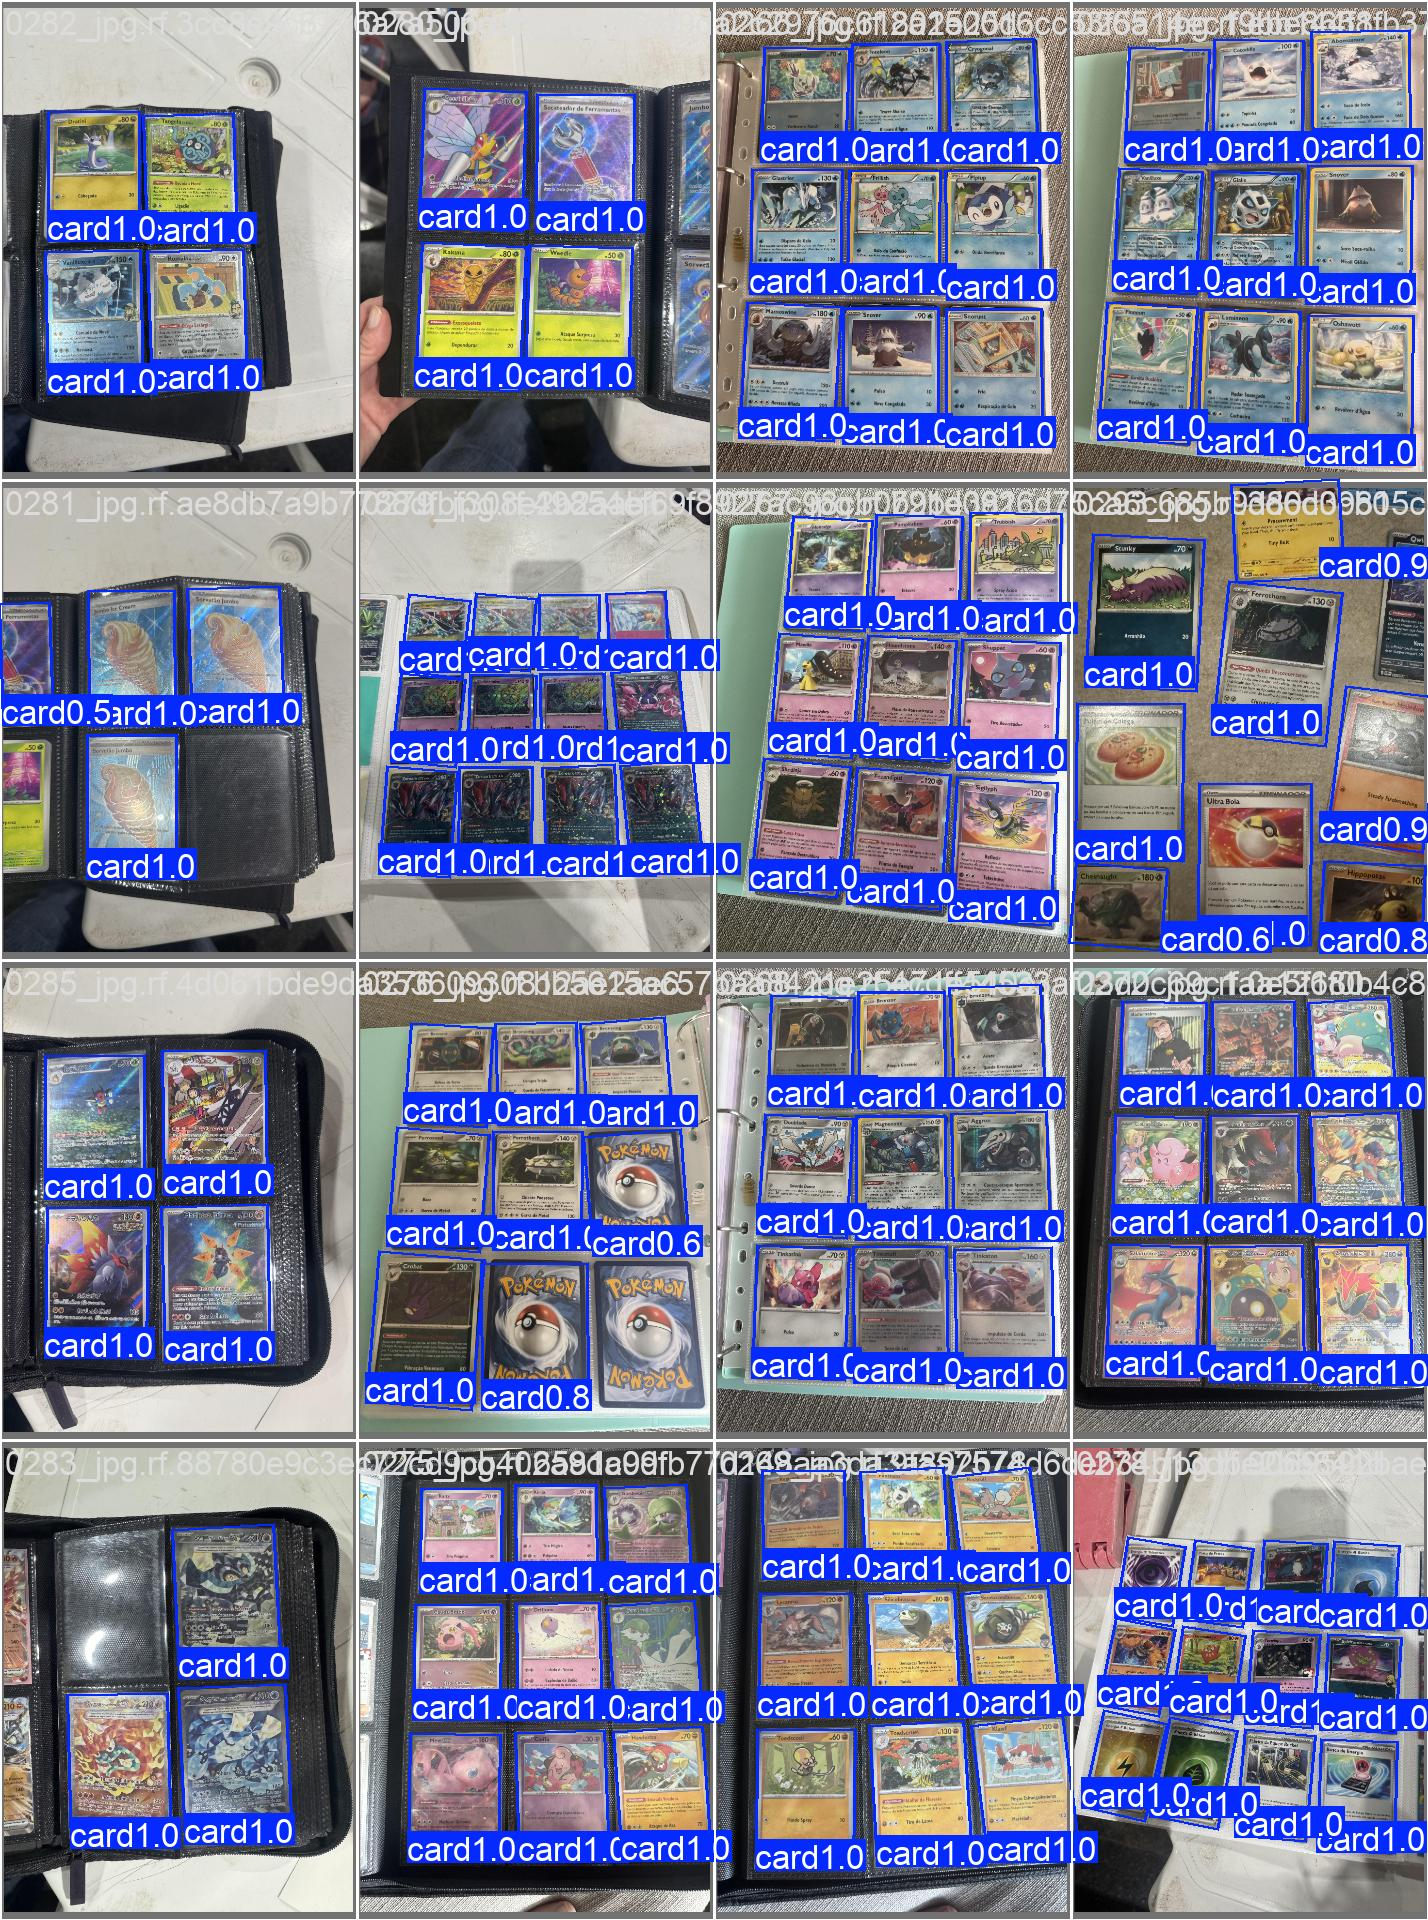

val_batch2_pred.jpg


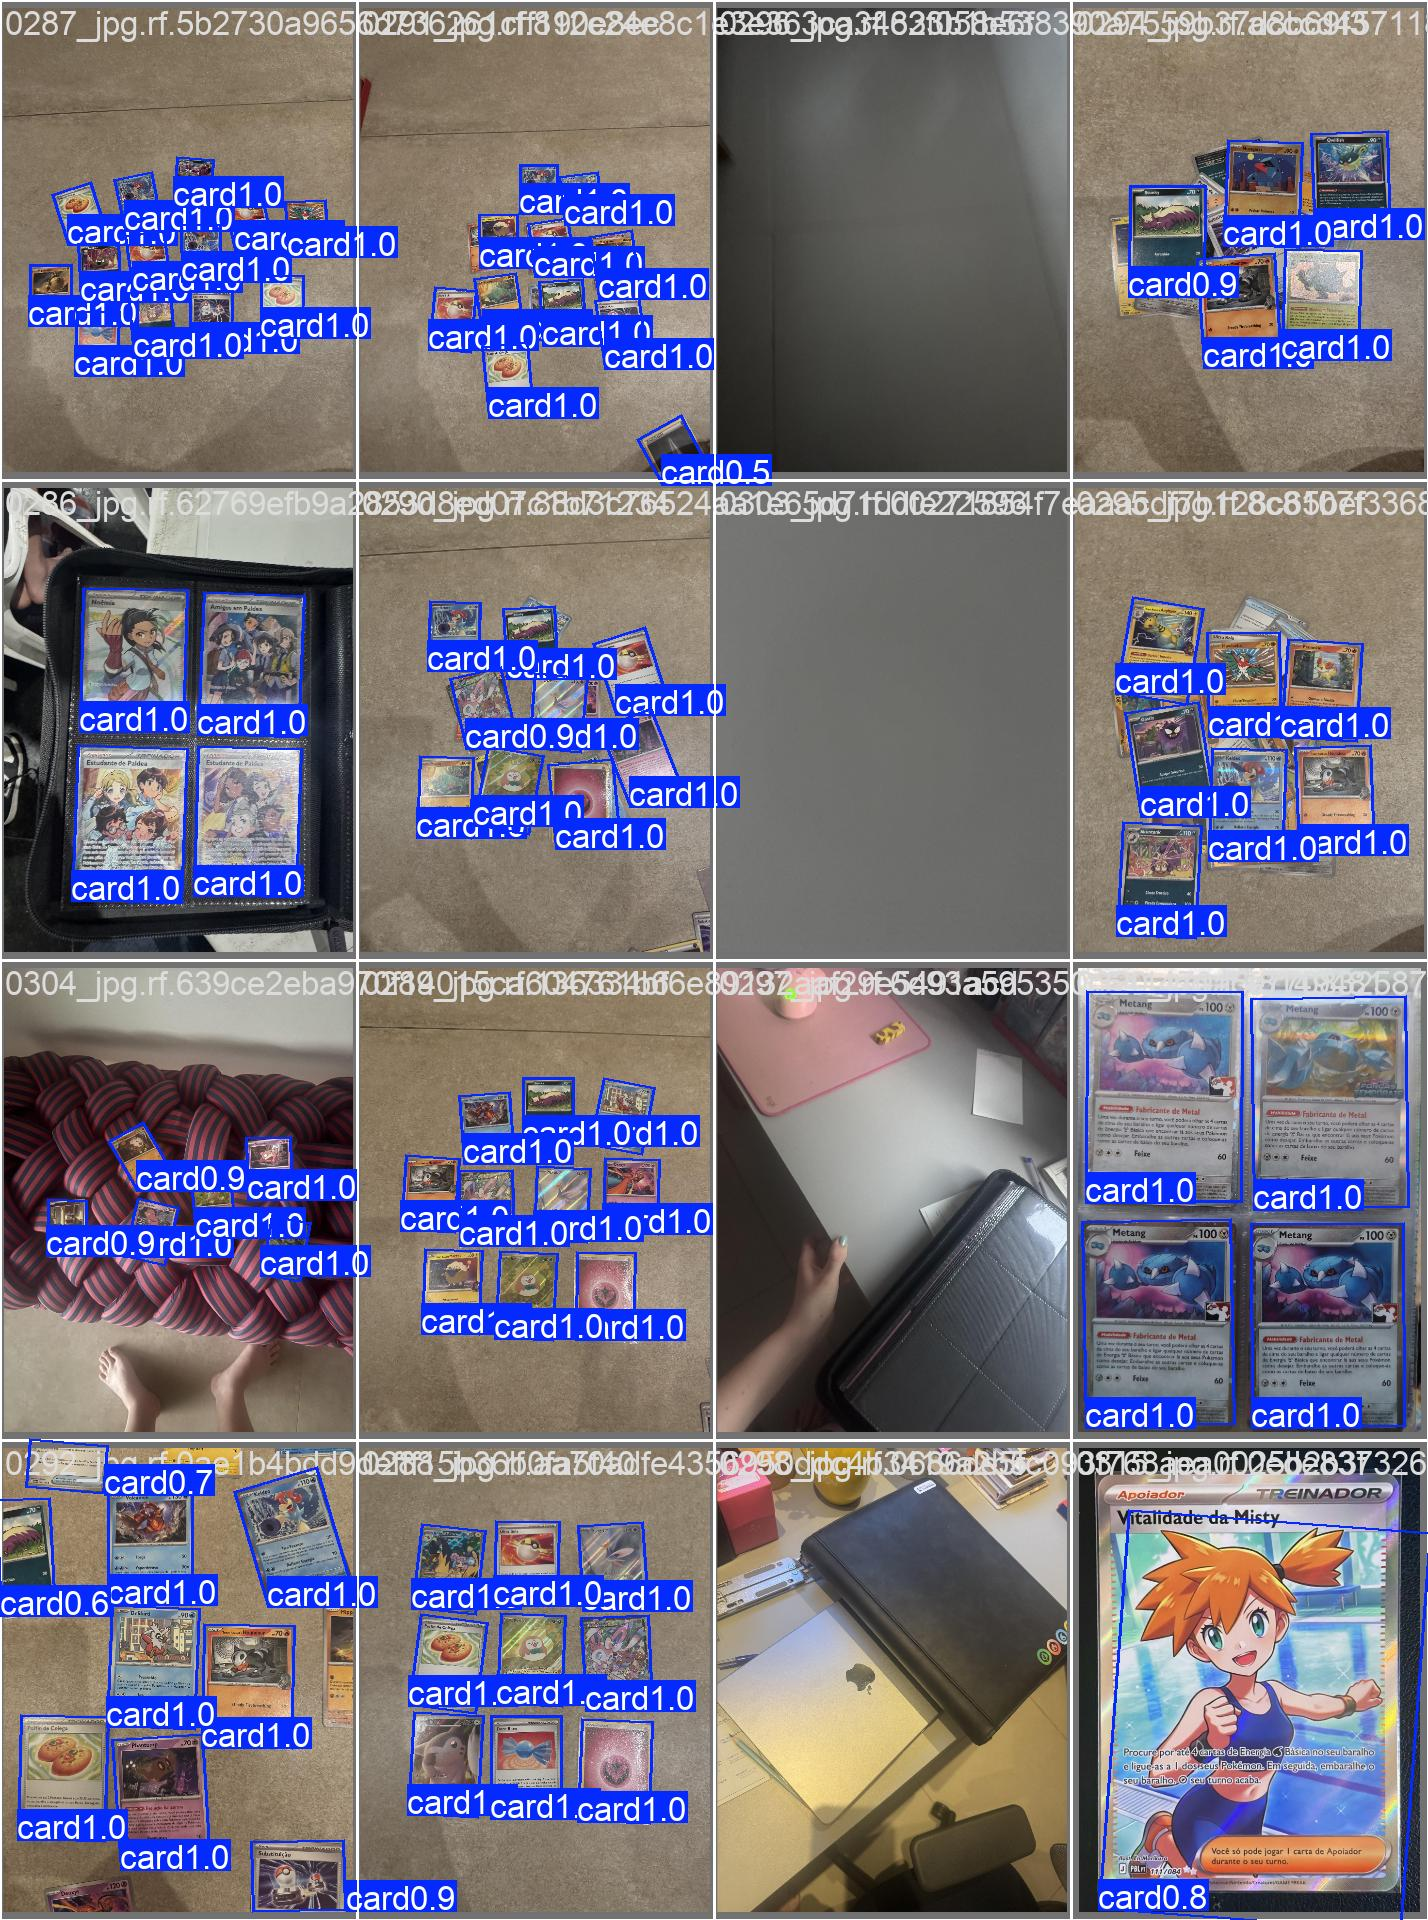

In [19]:
from IPython.display import Image as IPyImage, display as ipy_display

ARTIFACTS = [
    ("Curva F1 vs Confidence", "F1_curve.png"),
    ("Curva Precision–Recall", "PR_curve.png"),
    ("Curvas de treino (results.png)", "results.png"),
]
ARTIFACT_ALIASES = {
    "F1_curve.png": ["BoxF1_curve.png"],
    "PR_curve.png": ["BoxPR_curve.png"],
}


def find_artifact(run_dir: Path, filename: str) -> Path | None:
    names = [filename, *ARTIFACT_ALIASES.get(filename, [])]
    for name in names:
        direct = run_dir / name
        if direct.exists():
            return direct
        matches = sorted(run_dir.rglob(name))
        if matches:
            return matches[0]
    return None


print(f"Artefatos em: {RUN_DIR}\n")
for title, filename in ARTIFACTS:
    path = find_artifact(RUN_DIR, filename)
    if path is None:
        print(f"[ausente] {filename}")
        continue
    print(f"{title}  →  {path}")
    ipy_display(IPyImage(filename=str(path), width=720))

print("\nLotes de validação (labels vs predições)")
val_images = sorted(RUN_DIR.glob("val_batch*_labels.jpg")) + sorted(RUN_DIR.glob("val_batch*_pred.jpg"))
if not val_images:
    val_images = sorted(RUN_DIR.rglob("val_batch*.jpg"))

if not val_images:
    print("Nenhum lote de validação encontrado.")
else:
    for path in val_images:
        print(path.name)
        ipy_display(IPyImage(filename=str(path), width=720))


## 6. Renomeação dos pesos e exportação ONNX

1. Renomeia `runs/obb/obb-{VERSION}/weights/best.pt` → `obb-{VERSION}.pt`
2. Exporta o modelo final para ONNX como `obb-{VERSION}.onnx`


In [20]:
import shutil


def rename_best_weights(weights_dir: Path, experiment_name: str) -> Path:
    src = weights_dir / "best.pt"
    dst = weights_dir / f"{experiment_name}.pt"
    if dst.exists() and not src.exists():
        print(f"Pesos já renomeados: {dst}")
        return dst
    if not src.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {src}")
    if dst.exists():
        dst.unlink()
    src.rename(dst)
    print(f"Renomeado: {src.name} → {dst.name}")
    return dst


def export_onnx(pt_path: Path, experiment_name: str, imgsz: int, device: str) -> Path:
    export_model = YOLO(str(pt_path))
    produced = export_model.export(
        format="onnx",
        imgsz=imgsz,
        device=device,
        simplify=True,
        dynamic=False,
        opset=12,
    )
    produced_path = Path(str(produced))
    target = pt_path.with_name(f"{experiment_name}.onnx")

    if produced_path.resolve() != target.resolve():
        if target.exists():
            target.unlink()
        shutil.move(str(produced_path), str(target))

    print(f"ONNX exportado: {target}")
    return target


final_pt = rename_best_weights(WEIGHTS_DIR, EXPERIMENT_NAME)
final_onnx = export_onnx(final_pt, EXPERIMENT_NAME, IMGSZ, DEVICE)

print()
print("=" * 72)
print("Arquivos finais")
print("=" * 72)
for path in (final_pt, final_onnx, WEIGHTS_DIR / "last.pt"):
    if path.exists():
        size_mb = path.stat().st_size / 1024**2
        print(f"  {path.name:20s}  {size_mb:7.2f} MB  →  {path}")
    else:
        print(f"  {path.name:20s}  (ausente)")


Renomeado: best.pt → obb-v5.pt
Ultralytics 8.4.129  Python-3.14.7 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 5060, 8150MiB)
YOLOv8n-obb summary (fused): 82 layers, 3,077,414 parameters, 0 gradients, 18.7 GFLOPs

PyTorch: starting from 'C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb\obb-v5\weights\obb-v5.pt' with input shape (1, 3, 960, 960) BCHW and output shape(s) (1, 6, 18900) (6.3 MB)

ONNX: starting export with onnx 1.22.0 opset 12...
ONNX: slimming with onnxslim 0.1.96...
ONNX: export success  0.8s, saved as 'C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb\obb-v5\weights\obb-v5.onnx' (12.0 MB)

Export complete (0.9s)
Results saved to C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb\obb-v5\weights\obb-v5.onnx
Predict:         yolo predict task=obb model=C:\Users\Pichau\Documents\Repositorios\TCGTradeSegmentacao\src\detection\runs\obb\obb-v5\weights\obb-v5.onnx imgsz=960 
Validat

## Uso rápido do modelo exportado

```python
from ultralytics import YOLO

model = YOLO("src/detection/runs/obb/obb-v5/weights/obb-v5.pt")      # PyTorch
# model = YOLO("src/detection/runs/obb/obb-v5/weights/obb-v5.onnx")  # ONNX

results = model.predict("data/detection/test/images", conf=0.8, imgsz=960, save=True)
```

Para um novo experimento, altere `VERSION` no início do notebook (ex.: `"v6"`) e execute novamente. Os artefatos serão gravados em `runs/obb/obb-v6/`.
